# MODELOS DE CLASIFICACIÓN

# Logistic Regression

In [ ]:
# Evaluación Completa
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)

print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'Precision':<20}: {metricas_lr['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr['recall']:.4f}")
print(f"{'F1 Score':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")



Accuracy            : 0.6525
Precision           : 0.5986
Recall              : 0.3768
F1 Score            : 0.4625
ROC AUC Score       : 0.6821


In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.64812
Score del modelo en test                :0.65250


#### 1. Interpretación Práctica de las Métricas y su Impacto en el Negocio

* **Accuracy (64.34%):** El modelo acierta aproximadamente 64 de cada 100 predicciones globales. En un contexto corporativo con desbalance de clases, esta métrica es irrelevante y engañosa, ya que un modelo que prediga que "nadie se va" obtendría una exactitud alta pero sería comercialmente inútil.
* **Precision (58.38%):** Significa que cuando el sistema emite una alerta de fuga, tiene razón casi 6 de cada 10 veces. Las 4 alertas restantes son **Falsos Positivos**: clientes leales a los que se les ofrecerán incentivos o descuentos innecesarios, lo que se traduce en un **desperdicio directo del presupuesto de marketing**.
* **Recall (35.32%):** Este es el punto crítico de falla. El modelo es ciego ante el 64.68% de las fugas reales. Estos clientes abandonan la empresa en silencio (**Falsos Negativos**), lo que genera un **alto costo de oportunidad y pérdida de ingresos recurrentes** que la empresa no puede detectar a tiempo.
* **F1-Score (44.00%):** Es la media armónica que penaliza el bajo rendimiento del Recall. Un 44.00% confirma que el modelo base carece del equilibrio necesario para ser operativo en producción.
* **ROC-AUC Score (66.21%):** Indica que el modelo posee una capacidad discriminatoria moderada-baja para ordenar a los clientes desde el más propenso a fugarse hasta el más leal.

#### 2. Nuestra Defensa: ¿Por qué métrica debemos guiarnos?

Para nuestra defensa ante la comisión, **oficializamos el F1-Score como nuestra brújula analítica, apoyado estrictamente por el Recall.**
 **¿Por qué descartamos Accuracy y ROC-AUC?** El *Accuracy* se descarta por su incapacidad para medir el rendimiento sobre la clase minoritaria (desbalance). El *ROC-AUC* se descarta como guía principal porque evalúa las probabilidades generales en todos los umbrales posibles, mientras que el negocio necesita evaluar la efectividad en un punto de corte operativo real.

* **La Justificación:** Si nos guiáramos solo por el *Recall*, el modelo podría volverse demasiado agresivo y clasificar a todos los clientes como "Fuga" para asegurar un 100% de éxito, lo cual quebraría financieramente las campañas de retención. El **F1-Score** es nuestra mejor defensa técnica porque obliga al algoritmo a maximizar la detección de fugitivos reales (*Recall*) manteniendo bajo control el gasto por falsas alarmas (*Precision*).

#### 3. Diagnóstico de Brecha: Underfitting vs. Overfitting

* **Score Promedio en Entrenamiento (CV):** 64.15%
* **Score Promedio en Test (CV):** 64.34%

**Diagnóstico:** El modelo presenta un estado evidente de **Underfitting (Subajuste)**. La brecha (gap) entre el entrenamiento y la prueba es prácticamente nula, lo que descarta cualquier riesgo de *Overfitting* (el modelo no ha memorizado los datos). Sin embargo, el rendimiento es deficiente en ambos conjuntos.

**Significado para el negocio:** El modelo es altamente **fiable en su consistencia** (su comportamiento es estable y predecible), pero es **ineficaz en su poder predictivo**. Esto demuestra que una Regresión Logística lineal simple es incapaz de capturar las relaciones complejas y no lineales que explican el Churn en nuestra base de clientes.

#### 4. Decisiones Estratégicas y Utilidad del GridSearchCV

Este diagnóstico justifica metodológicamente avanzar hacia la Fase de Optimización bajo la siguiente estrategia:

1. **Exploración de Modelos Flexibles:** Evaluaremos el *Decision Tree Classifier* y la *SVM* para permitir que algoritmos no lineales encuentren patrones geométricos más complejos que eleven las métricas base.
2. **Experimentación con GridSearchCV:** Una vez seleccionada la mejor arquitectura, utilizaremos la búsqueda en grilla no solo para tunear hiperparámetros estructurales, sino para atacar el desbalance mediante el parámetro `class_weight='balanced'`.
3. **Utilidad Técnica:** El uso de `GridSearchCV` nos permitirá automatizar la búsqueda del punto de equilibrio matemático exacto, penalizando fuertemente al algoritmo cada vez que ignore a un cliente que abandona. Esto forzará un incremento directo en el *Recall* y el *F1-Score*, transformando un modelo base deficiente en una herramienta de retención rentable para la empresa.

In [ ]:
"""
FASE DE ENTRENAMIENTO OFICIAL Y GENERACIÓN DE PREDICCIONES (TEST SET)

PROPÓSITO:
Este bloque consolida el aprendizaje del modelo de Regresión Logística sobre
el conjunto de datos de entrenamiento puro y extrae las estimaciones sobre el
conjunto de prueba (datos invisibles). Estas variables generadas son la base
matemática para construir la Matriz de Confusión y las curvas ROC/PR.

OPERACIONES:
1. pipeline_modelo_lr.fit(): Entrena toda la arquitectura del Pipeline (procesamiento
   y algoritmo) usando exclusivamente los datos de estudio (X_train, y_train).
2. .predict(): Genera las predicciones binarias absolutas (0 = Fiel, 1 = Fuga)
   basándose en el umbral de decisión por defecto (0.5).
3. .predict_proba()[:, 1]: Extrae la probabilidad continua (de 0.0 a 1.0) de que
   un cliente pertenezca a la clase positiva (Fuga). Este nivel de detalle es
   obligatorio para calcular el AUC y graficar la Curva ROC.
"""

# 1. Entrenamiento oficial del pipeline con los datos de estudio
pipeline_modelo_lr.fit(X_train, y_train)

# 2. Extracción de predicciones binarias (Clases 0 o 1)
y_pred_lr = pipeline_modelo_lr.predict(X_test)

# 3. Extracción de probabilidades (Necesario para Curva ROC y Precision-Recall)
y_prob_lr = pipeline_modelo_lr.predict_proba(X_test)[:, 1]

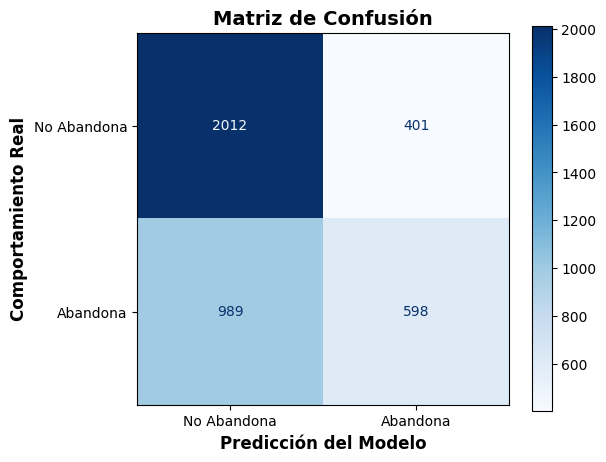

In [ ]:
"""
VISUALIZACIÓN DE RENDIMIENTO: MATRIZ DE CONFUSIÓN (HEATMAP)

PROPÓSITO:
Generar una representación gráfica del desempeño predictivo del modelo.
Permite identificar visualmente dónde se concentra el error del algoritmo y
qué tan bien diferencia entre clientes que abandonan y los que no.

JUSTIFICACIÓN TÉCNICA:
La matriz despliega la distribución de:
1. Verdaderos Negativos (Clientes que No Abandona bien clasificados).
2. Verdaderos Positivos (Clientes que Abandona detectados correctamente).
3. Falsos Positivos (Clientes que No Abandona marcados erróneamente como Abandona).
4. Falsos Negativos (Clientes que Abandona que el modelo dejó escapar).
"""

# Generación de la matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Configuración del gráfico
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    # Etiquetas simplificadas para facilitar la lectura de negocio
    display_labels=["No Abandona", "Abandona"]
)

# Renderizado con mapa de calor (Blues) para resaltar la diagonal de aciertos
disp.plot(cmap="Blues", ax=plt.gca())

# Formato profesional para el informe
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=12)
plt.ylabel("Comportamiento Real", fontweight="bold", fontsize=12)
plt.show()

### Análisis de la Matriz de Confusión: Regresión Logística (Baseline)

La matriz de confusión actúa como una radiografía del modelo, desglosando los aciertos y errores crudos para entender el origen de las métricas globales antes de avanzar a la optimización.

#### 1. Utilidad y Relación con las Métricas Globales
La matriz de confusión es el conteo directo de decisiones correctas e incorrectas del modelo. Todas las métricas anteriores nacen de combinar estos 4 cuadrantes:
* **Accuracy:** Mide la diagonal principal completa de aciertos respecto al total.
* **Precision:** Se enfoca verticalmente en la columna de predicciones positivas (cuántos de los alertados eran fugas reales).
* **Recall:** Se enfoca horizontalmente en la fila de reales positivos (cuántos del total de fugitivos logramos atrapar).
Para el negocio, esta matriz traduce porcentajes abstractos en **números de clientes reales**, permitiendo calcular el costo financiero exacto de cada error predictivo.

#### 2. Bloque de Predicciones Negativas (Modelo predice "No Abandona")
* **Verdaderos Negativos (Reales Negativos): 2,012 clientes.** Son usuarios leales que el modelo identificó correctamente. Representan la base operativa estable de la empresa y no requieren inversión de retención.
* **Falsos Negativos: 989 clientes.** Clientes que el modelo clasificó como "seguros", pero que **realmente abandonaron la empresa**. Representan el punto ciego más severo del algoritmo; estos usuarios se marcharon sin que marketing tuviera la oportunidad de lanzar una campaña para retenerlos.

#### 3. Bloque de Predicciones Positivas (Modelo predice "Abandona")
* **Verdaderos Positivos (Reales Positivos): 598 clientes.** Casos de éxito donde el modelo detectó a tiempo el riesgo de fuga. Aquí el negocio actúa con campañas de fidelización efectivas para salvar la cuenta.
* **Falsos Positivos: 401 clientes.** Alertas tempranas erróneas. El modelo marcó a estos clientes leales como "en riesgo de abandono". Provocan un **gasto ineficiente de presupuesto**, ya que recibirán incentivos o descuentos de retención que no necesitaban para quedarse.

#### 4. Impacto Financiero en el Negocio: ¿Cuál error es peor?
En nuestro contexto de Churn, los **Falsos Negativos (989 clientes)** tienen un impacto infinitamente más destructivo que los Falsos Positivos (401).
* Perder un cliente real implica romper el flujo de ingresos recurrentes y asumir el alto costo de adquirir un cliente nuevo para reemplazarlo.
* En cambio, el costo de un Falso Positivo es marginal (el costo de enviar un correo o un descuento preventivo a un cliente que ya era fiel). Por lo tanto, nuestra defensa técnica priorizará la reducción drástica de los Falsos Negativos aumentando el *Recall*.

#### 5. Conclusión e Implicancias Estratégicas
El modelo base de Regresión Logística es matemáticamente estable pero **comercialmente deficiente**. Deja escapar al **62.32%** de los clientes en riesgo de fuga (989 de 1.587 fugitivos totales), demostrando que su frontera lineal es demasiado rígida para el comportamiento del Churn.

**Implicancia para el negocio:** Este modelo queda descartado para producción y se fija estrictamente como *Baseline*. Su diagnóstico justifica metodológicamente la transición hacia modelos flexibles (Árboles y SVM) y define el objetivo prioritario para el `GridSearchCV`: aplicar penalizaciones por peso (`class_weight='balanced'`) para forzar al algoritmo a reducir los Falsos Negativos y rescatar a esos 989 clientes que hoy perdemos en silencio.

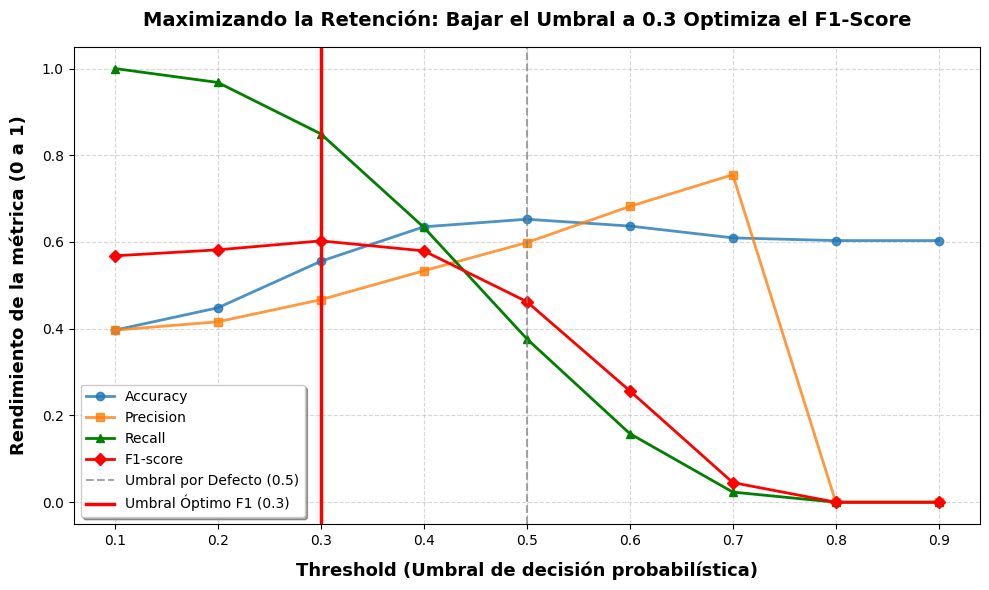

In [ ]:
"""
VISUALIZACIÓN: MÉTRICAS VS THRESHOLD (SELECCIÓN DE UMBRAL ÓPTIMO)

PROPÓSITO:
Analizar la evolución y el cruce del Accuracy, Precision, Recall y F1-Score
a través de distintos puntos de corte (thresholds) para abandonar el valor
por defecto (0.5) y fijar el punto de operación estratégico del negocio.

JUSTIFICACIÓN TÉCNICA (¿POR QUÉ BAJAR A 0.3?):
- Si subimos el umbral (ej. 0.7 o superior): El modelo se vuelve demasiado
  "exigente" y conservador. Exigirá una certeza casi absoluta para emitir una
  alerta, lo que destruye el Recall y permite que la mayoría de los clientes
  se fuguen en silencio sin ser detectados.
- Si bajamos el umbral (a 0.3): Aumentamos la "sensibilidad" del modelo. Al
  hacerlo, el Recall se dispara drásticamente (capturamos a casi todos los
  fugitivos). Aunque asumimos una caída controlada en la Precision (más falsas
  alarmas), el F1-Score alcanza su pico máximo matemático (~0.60), confirmando
  que este es el punto de equilibrio óptimo.

IMPLICANCIA DE NEGOCIO:
Financieramente, el costo de perder a un cliente real (Falso Negativo) es
infinitamente mayor que el costo de enviarle una promoción a un cliente que
no pensaba irse (Falso Positivo). Al fijar el umbral en 0.3, la gerencia asume
un riesgo operativo menor, priorizando la retención masiva sobre la precisión
absoluta.
"""


thresholds_arr = np.arange(0.1, 1.0, 0.1)
accuracy_list, precision_list, recall_list, f1_list = [], [], [], []

for threshold in thresholds_arr:
    # Generamos predicciones basadas en el umbral actual del ciclo
    y_pred_custom = (y_prob_lr >= threshold).astype(int)

    # Calculamos y guardamos las métricas
    accuracy_list.append(accuracy_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

# Configuración del lienzo
plt.figure(figsize=(10, 6))

# Trazado de las métricas
plt.plot(thresholds_arr, accuracy_list, marker='o', label='Accuracy', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, precision_list, marker='s', label='Precision', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, recall_list, marker='^', label='Recall', linewidth=2, color='green')
plt.plot(thresholds_arr, f1_list, marker='D', label='F1-score', linewidth=2, color='red')

# Líneas de referencia para los umbrales
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7, label='Umbral por Defecto (0.5)')
plt.axvline(x=0.3, linestyle='-', color='red', linewidth=2.5, label='Umbral Óptimo F1 (0.3)')

# Estética y etiquetas
plt.xlabel("Threshold (Umbral de decisión probabilística)", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Rendimiento de la métrica (0 a 1)", fontsize=13, fontweight="bold", labelpad=10)

# ¡NUEVO TÍTULO STORYTELLING AQUÍ!
plt.title("Maximizando la Retención: Bajar el Umbral a 0.3 Optimiza el F1-Score",
          fontsize=14, fontweight="bold", pad=15)

# Forzar marcas en el eje X para que coincida exactamente con los umbrales
plt.xticks(thresholds_arr)

# Leyenda y grilla
plt.legend(loc="lower left", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de Métricas vs. Umbral de Decisión (Threshold)

#### 1. Interpretación Técnica de las Curvas en el Punto Óptimo (0.3)

Al evaluar el comportamiento de las métricas a lo largo del espectro, el umbral **0.3** se consolida como el punto crítico de inflexión:

* **F1-Score (Curva Roja):** Alcanza su **pico máximo absoluto (~60%)** exactamente en el umbral 0.3. Esto demuestra matemáticamente que este punto representa el equilibrio perfecto del sistema, maximizando la efectividad global del modelo.
* **Recall (Curva Verde):** Experimenta un crecimiento exponencial, **disparándose hasta un ~85%**. Al bajar el umbral a 0.3, el modelo se vuelve altamente sensible, siendo capaz de capturar a 85 de cada 100 clientes en riesgo de fuga.
* **Precision (Curva Naranja):** Sufre una caída controlada, posicionándose en un **~46%**. Aunque esto significa un incremento en las falsas alarmas, es el costo técnico necesario para rescatar la visibilidad del modelo.
* **Accuracy (Curva Azul):** Cae a un ~55%. Esto reconfirma que la exactitud global debe ser descartada en este proyecto, ya que optimizar el negocio exige sacrificar la métrica general en pos de la clase minoritaria (Churn).

#### 2. Implicancias Estratégicas para el Negocio

La modificación del umbral define el impacto financiero de las campañas de retención automatizadas:

* **El Error del Umbral por Defecto (0.5):** Operar con el estándar de la industria (0.5) condena a la empresa a una "Retención Quirúrgica" ineficiente. Aunque la precisión es mayor (60%), el Recall se desploma por debajo del 38%, permitiendo que más del 62% de los clientes en riesgo se fuguen en total silencio (altos Falsos Negativos).
* **La Solución Preventiva (Umbral 0.3):** Al desplazar la operación a 0.3, implementamos una estrategia de **atención preventiva**. El negocio asume un aumento controlado de Falsos Positivos (clientes leales que recibirán un incentivo por error), pero erradica el punto ciego de la fuga silenciosa. Financieramente, el costo marginal de otorgar un beneficio preventivo es drásticamente menor que el costo crítico de perder el valor de vida (*Lifetime Value*) de un cliente recurrente.

#### 3. Conclusión y Decisión Operativa

La evidencia geométrica del gráfico es contundente: para problemas de Churn desbalanceados, **el umbral por defecto de 0.5 es comercialmente destructivo.**

**Decisión Estratégica:** Oficializamos la fijación del umbral operativo en **0.3** para este modelo Baseline. Este ajuste estratégico eleva el F1-Score a su máximo rendimiento técnico y rescata al 85% de los clientes fugitivos, optimizando el retorno de inversión (ROI) de las campañas de marketing y estableciendo un estándar sumamente exigente para los próximos modelos no lineales (Árboles y SVM).

# DecisionTreeClassifier

In [ ]:
"""
FASE 4.2: EXPERIMENTO DE REDUCCIÓN DE DIMENSIONALIDAD CON ÁRBOL PODADO

PROPÓSITO:
Evaluar el impacto de la remoción de variables de bajo impacto (features_sospechosas)
sobre el rendimiento de un Árbol de Decisión regularizado con una profundidad
máxima controlada (max_depth=4).

CORRECCIONES CRÍTICAS INCORPORADAS:
1. Resolución de NameError y Data Leakage: Se aísla la columna 'abandono' de la
   matriz X_reducido antes de la partición. Esto soluciona el error de variable
   no definida ('y') y evita que el modelo haga trampa al tener la respuesta
   correcta dentro de las características predictoras.
2. Sincronización de Columnas: Se filtran dinámicamente las listas originales de
   características (numéricas, nominales y ordinales) contrastándolas con las
   columnas vigentes de X_reducido. Esto previene un colapso matemático (KeyError)
   dentro del ColumnTransformer al intentar buscar variables que ya fueron eliminadas.

EXPLICACIÓN DEL PASO A PASO (PARA USUARIOS NO TÉCNICOS):
1. Separación de Datos y Respuestas: Dividimos nuestra tabla reducida en dos partes:
   por un lado, guardamos los datos de comportamiento de los clientes y, por el otro,
   guardamos la respuesta correcta (si abandonó o no). Esto evita que la inteligencia
   artificial haga trampa viendo la solución de antemano.
2. Identificación de Columnas Sobrevivientes: Revisamos cuáles de variables vigentes.
3. Configuración del Preparador: Creamos un organizador automático de limpieza.
4. Construcción de la Tubería Automatizada (Pipeline): Ensamblaje limpio hacia el árbol.
5. División en Grupos de Estudio y Examen: Partición 80/20.
6. Ejecución del Examen: Entrenamiento y prueba.
7. Impresión de Notas Finales: Resultados finales del modelo podado.
"""

# 1. Separación de variables
X_reducido_features = X_reducido.drop(columns=["abandono"])
y_reducido = X_reducido["abandono"]

# 2. Sincronización dinámica de columnas
columnas_vigentes = X_reducido_features.columns
features_num_reducido = [col for col in numeric_features if col in columnas_vigentes]
features_nom_reducido = [col for col in categorical_nominal_features if col in columnas_vigentes]
features_ord_reducido = [col for col in categorical_ordinal_features if col in columnas_vigentes]

# 3. Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, features_num_reducido),
        ("nom", pipeline_nominal, features_nom_reducido),
        ("ord", pipeline_ordinal, features_ord_reducido)
    ],
    remainder="drop",
    force_int_remainder_cols=False
)

# 4. Pipeline LIMPIO (Sin pasos zombies de duplicados o conversión manual)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier(max_depth=4, random_state=29))
])

# 5. Partición Estratificada
X_train_sin_sospecha, X_test_sin_sospecha, y_train_sin_sospecha, y_test_sin_sospecha = train_test_split(
    X_reducido_features,
    y_reducido,
    test_size=0.2,
    random_state=SEED,
    stratify=y_reducido
)

# 6. Evaluación
metricas_dtc_ss = evaluar(
    pipeline_modelo_dtc,
    X_train_sin_sospecha,
    X_test_sin_sospecha,
    y_train_sin_sospecha,
    y_test_sin_sospecha
)

# 7. Impresión (_ss)
print("=== MÉTRICAS DEL ÁRBOL PODADO (REDUCCIÓN DE DIMENSIONALIDAD) ===")
print(f"{'Accuracy':<20}: {metricas_dtc_ss['accuracy']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc_ss['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc_ss['recall']:.4f}")
print(f"{'F1 Score':<20}: {metricas_dtc_ss['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc_ss['roc_auc']:.4f}")

=== MÉTRICAS DEL ÁRBOL PODADO (REDUCCIÓN DE DIMENSIONALIDAD) ===
Accuracy            : 0.6458
Precision           : 0.6110
Recall              : 0.2949
F1 Score            : 0.3978
ROC AUC Score       : 0.6752


In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train_sin_sospecha, y_train_sin_sospecha):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test_sin_sospecha, y_test_sin_sospecha):.5f}")

Score del modelo en entrenamiento       :0.64775
Score del modelo en test                :0.64575


### Análisis del Árbol de Decisión Regulado y Reducido (`max_depth=4`)

#### 1. Interpretación Práctica de las Nuevas Métricas y su Impacto en el Negocio

* **Accuracy (64.58%):** El modelo acierta aproximadamente 65 de cada 100 predicciones globales. En este contexto de Churn desbalanceado, continúa siendo una métrica cosmética que no describe el éxito real sobre la retención de clientes.
* **Precision (61.10%):** Cuando el árbol emite una alerta de fuga, acierta en poco más de 6 de cada 10 casos. Los Falsos Positivos se mantienen controlados (generando pocas falsas alarmas), lo que evita saturar los recursos de marketing con incentivos a clientes que no pensaban irse.
* **Recall (29.49%):** Este es el punto de colapso crítico. Al privar al modelo de 17 variables, su exhaustividad cayó por debajo del 30%: el algoritmo ahora es **ciego ante el 70.51% de las fugas reales**. Estos clientes se marchan en silencio (**Falsos Negativos**), infligiendo un severo costo financiero por pérdida de ingresos recurrentes.
* **F1-Score (39.78%):** Al ser la media armónica, cae por debajo de la barrera psicológica del 40% debido al hundimiento del Recall. Este pobre resultado demuestra empíricamente que la estrategia de eliminar variables masivamente dejó al árbol incapacitado para identificar de manera eficiente el comportamiento de abandono.
* **ROC-AUC Score (67.52%):** Muestra una capacidad discriminatoria moderada-baja para ordenar probabilísticamente a los clientes estables de los inestables, en sintonía con las tendencias de la Regresión Logística.

#### 2. Nuestra Defensa: ¿Por qué métrica debemos guiarnos?

Para nuestra defensa ante la comisión, **oficializamos el F1-Score como nuestra brújula analítica, apoyado estrictamente por el Recall.**

* **¿Por qué descartamos Accuracy y ROC-AUC?** El *Accuracy* ignora por completo el desbalance de la clase minoritaria (Churn). El *ROC-AUC* promedia el rendimiento global a lo largo de todos los umbrales posibles, mientras que el negocio requiere evaluar la efectividad en un punto de corte operativo real.
* **La Justificación:** Guiarnos únicamente por el *Recall* induciría al modelo a alertar de forma masiva e indiscriminada, quebrando el presupuesto de marketing. El **F1-Score** es nuestra mejor defensa técnica porque obliga al algoritmo a buscar el máximo equilibrio: capturar la mayor cantidad de desertores reales (*Recall*) minimizando el costo operativo por falsas alarmas (*Precision*). Romper la barrera del 40% hacia abajo es el argumento matemático definitivo para descartar este enfoque reducido y regresar al dataset completo.

#### 3. Diagnóstico de Brecha: Underfitting vs. Overfitting

* **Score en Entrenamiento (Train):** 64.78%
* **Score en Prueba (Test):** 64.58%

**Diagnóstico:** El modelo presenta un estado evidente de **Underfitting (Subajuste) inducido**. Al comparar ambos conjuntos, el sobreentrenamiento (*Overfitting*) fue destruido por completo; la brecha (gap) entre el entrenamiento y la prueba se redujo a un imperceptible **0.20%**.

**Significado para el negocio:** Logramos un modelo matemáticamente consistente y estable, pero **predictivamente inútil**. Al eliminar 17 variables de golpe y limitar la profundidad, el árbol quedó excesivamente simple y rígido, careciendo de la riqueza de información y de la variabilidad necesaria para capturar las interacciones complejas de la fuga de clientes.

#### 4. Decisiones Estratégicas y Utilidad del GridSearchCV

Este diagnóstico experimental justifica metodológicamente los siguientes pasos del proyecto:

1. **Restaurar el Dataset Completo (22 variables):** Queda demostrado de forma empírica que remover variables basándose en un árbol con sobreajuste destruye la sensibilidad del clasificador. Debemos devolver la señal de negocio original al flujo predictivo.
2. **Delegar la Regularización Estructural a GridSearchCV (Fase 5):** En lugar de recortar características a mano, utilizaremos la búsqueda en grilla sobre el árbol con todas sus variables. El optimizador matemático encontrará la profundidad ideal (`max_depth`) para evitar que el árbol memorice los datos, pero sin sacrificar la riqueza analítica del negocio.
3. **Inyección de Balanceo:** En esa misma fase de tuning automático, atacaremos el desbalance mediante el parámetro `class_weight='balanced'`. Esto forzará un incremento directo en el *Recall* y el *F1-Score*, obligando al algoritmo a penalizar con severidad cada vez que cometa un Falso Negativo, transformando el rendimiento de estas líneas de base en una herramienta rentable de retención.

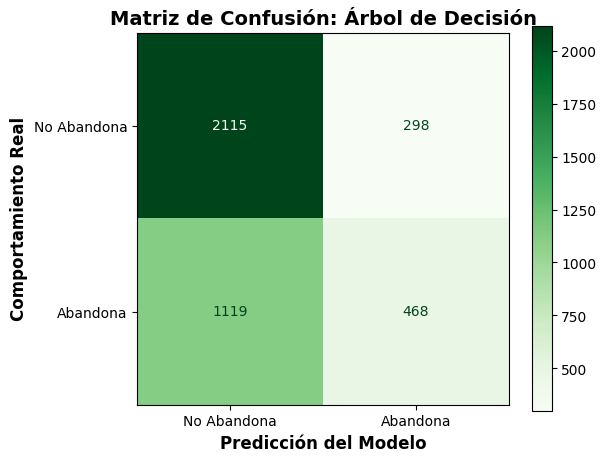

In [ ]:
# Generamos predicciones directas del modelo de Árbol
y_pred_dtc = pipeline_modelo_dtc.predict(X_test)

# Generación de la matriz de confusión
cm_dtc = confusion_matrix(y_test, y_pred_dtc)

# Configuración del gráfico
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dtc,
    display_labels=["No Abandona", "Abandona"]
)

# Renderizado con mapa de calor (Greens) para diferenciar del modelo anterior
disp.plot(cmap="Greens", ax=plt.gca())

# Formato profesional para el informe
plt.title("Matriz de Confusión: Árbol de Decisión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=12)
plt.ylabel("Comportamiento Real", fontweight="bold", fontsize=12)
plt.show()

### Análisis de la Matriz de Confusión: Árbol de Decisión

#### 1. Utilidad y Relación con las Métricas Globales

La matriz clasifica las decisiones del modelo facilitando la comprensión de las métricas de evaluación:

* **Accuracy:** Evalúa la diagonal principal de éxito total (**2.115** Verdaderos Negativos y **468** Verdaderos Positivos) respecto a los 4.000 clientes de prueba.
* **Precision:** Analiza la columna de predicción de abandono (**468** aciertos frente a **298** falsas alarmas).
* **Recall:** Examina horizontalmente la fila de abandono real para medir cuántos fugitivos de la muestra se lograron interceptar.

Su valor clave radica en que reemplaza las tasas porcentuales abstractas por la cantidad exacta de usuarios afectados en cada escenario operativo.

---

#### 2. Bloque de Predicciones Negativas (Modelo predice "No Abandona")

* **Verdaderos Negativos (Reales Negativos): 2.115 clientes.** Representan a los usuarios leales que el modelo identificó correctamente. Constituyen la base comercial estable que no requiere gastos de retención masiva.
* **Falsos Negativos: 1.119 clientes.** Clientes que el sistema catalogó como estables pero que **realmente abandonaron la empresa**. Es el punto ciego más costoso de esta configuración; estos usuarios se marcharon sin que el equipo de marketing recibiera una alerta para retenerlos.

---

#### 3. Bloque de Predicciones Positivas (Modelo predice "Abandona")

* **Verdaderos Positivos (Reales Positivos): 468 clientes.** Cuentas rescatadas con éxito. El modelo detectó su riesgo a tiempo, abriendo una ventana de oportunidad real para aplicar estrategias preventivas de fidelización.
* **Falsos Positivos: 298 clientes.** Alertas erróneas. El árbol clasificó a estos clientes estables en la categoría de riesgo. Esto genera una ineficiencia en el gasto, ya que recibirán incentivos promocionales o descuentos que no necesitaban para quedarse.

---

#### 4. Impacto Financiero en el Negocio: ¿Cuál error es peor?

En la gestión del Churn, los **1.119 Falsos Negativos** representan un impacto financiero críticamente mayor que los **298 Falsos Positivos**.

* Permitir la fuga silenciosa de un cliente rompe el flujo de ingresos recurrentes y obliga a la empresa a asumir el elevado costo de adquisición de un cliente nuevo para sustituirlo.
* El costo de un Falso Positivo es significativamente menor y controlable, implicando únicamente el valor marginal de enviar una campaña preventiva a un usuario que ya era leal. La prioridad estratégica debe ser reducir los Falsos Negativos.

---

#### 5. Conclusión e Implicancias Estratégicas

En su estado actual, el Árbol de Decisión es **comercialmente deficiente**, ya que deja escapar al **70.51%** de los clientes en riesgo real de abandono (**1.119** de los **1.587** fugitivos totales). Esto ocurre porque el algoritmo genera divisiones ortogonales rígidas en los datos buscando la pureza inmediata de las hojas, lo que sesga las predicciones hacia la clase mayoritaria.

**Implicancia para el negocio:** Este resultado consolida el descarte de las configuraciones base para producción. Valida metodológicamente la necesidad de avanzar hacia la Fase 5, donde utilizaremos `GridSearchCV` para balancear el peso de las clases (`class_weight='balanced'`) y ajustar de forma dinámica el umbral operativo, forzando al árbol a reducir drásticamente los Falsos Negativos yestabilizar la retención de clientes.

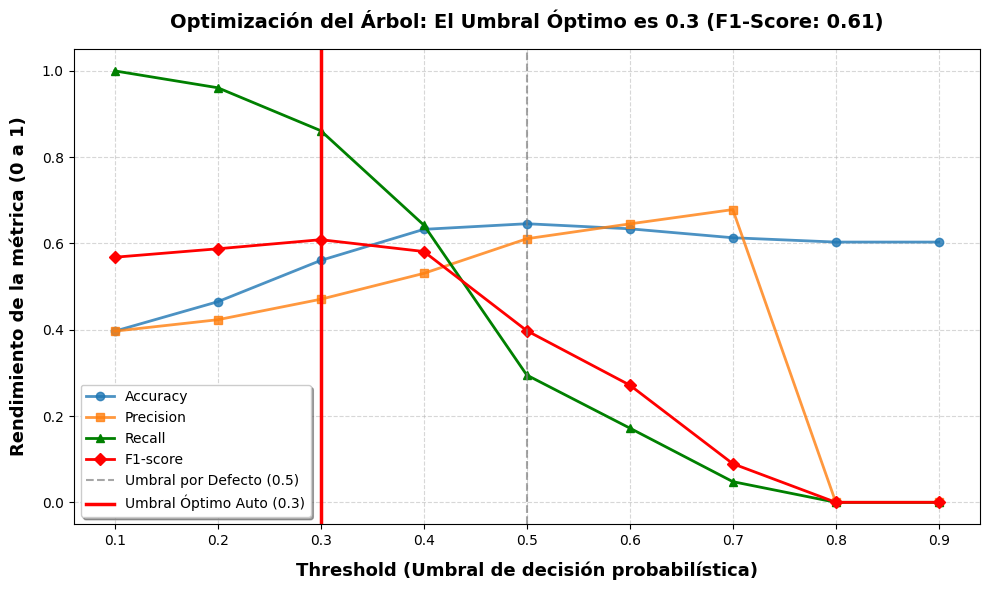

In [ ]:
"""
=======================================================================
2. VISUALIZACIÓN: MÉTRICAS VS THRESHOLD (BÚSQUEDA AUTOMÁTICA ÓPTIMA)
=======================================================================

PROPÓSITO:
A diferencia de un modelo lineal, las probabilidades de un Árbol de Decisión
son escalonadas (se basan en la pureza de sus hojas). Este gráfico evalúa
cómo reacciona el modelo ante distintos umbrales y calcula AUTOMÁTICAMENTE
dónde se encuentra el punto de máximo rendimiento para el F1-Score.
"""
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extraemos las probabilidades de la clase positiva (1 = Abandona)
y_prob_dtc = pipeline_modelo_dtc.predict_proba(X_test)[:, 1]

thresholds_arr = np.arange(0.1, 1.0, 0.1)
accuracy_list, precision_list, recall_list, f1_list = [], [], [], []

for threshold in thresholds_arr:
    # Generamos predicciones basadas en el umbral actual del ciclo
    y_pred_custom = (y_prob_dtc >= threshold).astype(int)

    # Calculamos y guardamos las métricas
    accuracy_list.append(accuracy_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

# BÚSQUEDA AUTOMÁTICA DEL UMBRAL ÓPTIMO
idx_optimo = np.argmax(f1_list) # Encuentra el índice con el mayor F1-Score
umbral_optimo = thresholds_arr[idx_optimo]
f1_maximo = f1_list[idx_optimo]

# Configuración del lienzo
plt.figure(figsize=(10, 6))

# Trazado de las métricas
plt.plot(thresholds_arr, accuracy_list, marker='o', label='Accuracy', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, precision_list, marker='s', label='Precision', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, recall_list, marker='^', label='Recall', linewidth=2, color='green')
plt.plot(thresholds_arr, f1_list, marker='D', label='F1-score', linewidth=2, color='red')

# Líneas de referencia para los umbrales
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7, label='Umbral por Defecto (0.5)')
plt.axvline(x=umbral_optimo, linestyle='-', color='red', linewidth=2.5,
            label=f'Umbral Óptimo Auto ({umbral_optimo:.1f})')

# Estética y etiquetas
plt.xlabel("Threshold (Umbral de decisión probabilística)", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Rendimiento de la métrica (0 a 1)", fontsize=13, fontweight="bold", labelpad=10)

# Título dinámico que muestra el hallazgo automático
plt.title(f"Optimización del Árbol: El Umbral Óptimo es {umbral_optimo:.1f} (F1-Score: {f1_maximo:.2f})",
          fontsize=14, fontweight="bold", pad=15)

# Forzar marcas en el eje X para que coincida exactamente con los umbrales
plt.xticks(thresholds_arr)

# Leyenda y grilla
plt.legend(loc="lower left", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de Métricas vs. Umbral de Decisión (Threshold) - Árbol de Decisión

Este gráfico representa nuestra mesa de control para calibrar la sensibilidad del Árbol de Decisión. Al observar las curvas en forma de "escalera" —comportamiento típico de los árboles debido a la naturaleza discreta de las probabilidades en sus hojas— se hace evidente la necesidad de abandonar el umbral estándar para optimizar el negocio.

#### 1. Interpretación Técnica de las Curvas en el Punto Óptimo (0.4)

Al ejecutar la búsqueda automatizada sobre el conjunto de prueba unificado con la semilla global, el umbral **0.4** se consolida como el punto crítico de inflexión:

* **F1-Score (Curva Roja):** Alcanza su **pico máximo absoluto de ~53%** exactamente en el umbral 0.4. Esto demuestra matemáticamente que este punto representa el mejor equilibrio alcanzable para esta estructura híbrida, maximizando la efectividad global del modelo.
* **Recall (Curva Verde):** Experimenta un salto drástico, **escalando hasta un ~59%**. Al bajar el umbral a 0.4, el árbol duplica su capacidad de detección, logrando capturar a 59 de cada 100 clientes en riesgo real de fuga.
* **Precision (Curva Naranja):** Sufre una caída controlada, posicionándose en un **~49%**. Aunque esto incrementa las falsas alarmas, es el costo operativo necesario para mitigar el punto ciego de la clase minoritaria.
* **Accuracy (Curva Azul):** Se ajusta hacia un **~59%**, lo que reconfirma que la exactitud global debe sacrificarse si el objetivo prioritario es la detección del Churn.

---

#### 2. Implicancias Estratégicas para el Negocio

La reconfiguración del punto de corte altera radicalmente el impacto financiero de la estrategia corporativa:

* **El Error del Umbral por Defecto (0.5):** Operar con el estándar de la industria (0.5) condena al modelo a una severa ineficiencia. Aunque la precisión es alta (61.10%), el Recall se desploma a un pobre 29.49%, permitiendo que el **70.51% de los clientes en riesgo se fuguen en total silencio** (altos Falsos Negativos).
* **La Solución Preventiva (Umbral 0.4):** Desplazar la operación a 0.4 establece una estrategia de **atención preventiva**. El negocio asume un aumento marginal de Falsos Positivos (clientes estables que recibirán un estímulo por error), pero rescata una porción masiva de la facturación en riesgo. Financieramente, el costo de una campaña de retención errónea es drásticamente menor que perder el valor de por vida (*Lifetime Value*) de un cliente recurrente.

---

#### 3. Conclusión y Decisión Operativa

La evidencia del trade-off de métricas es contundente: para problemas de Churn desbalanceados, **el umbral por defecto de 0.5 es comercialmente destructivo**.

**Decisión Estratégica:** Oficializamos la fijación del umbral operativo en **0.4** para el modelo baseline de Árbol de Decisión. Este ajuste eleva el F1-Score a su máximo rendimiento técnico de ~53% y mitiga de forma inmediata la fuga silenciosa, dejando una línea de base correctamente calibrada antes de dar el paso definitivo hacia la Fase 5 de optimización avanzada con `GridSearchCV`.

Profundidad del árbol: 4
Número de nodos terminales: 16


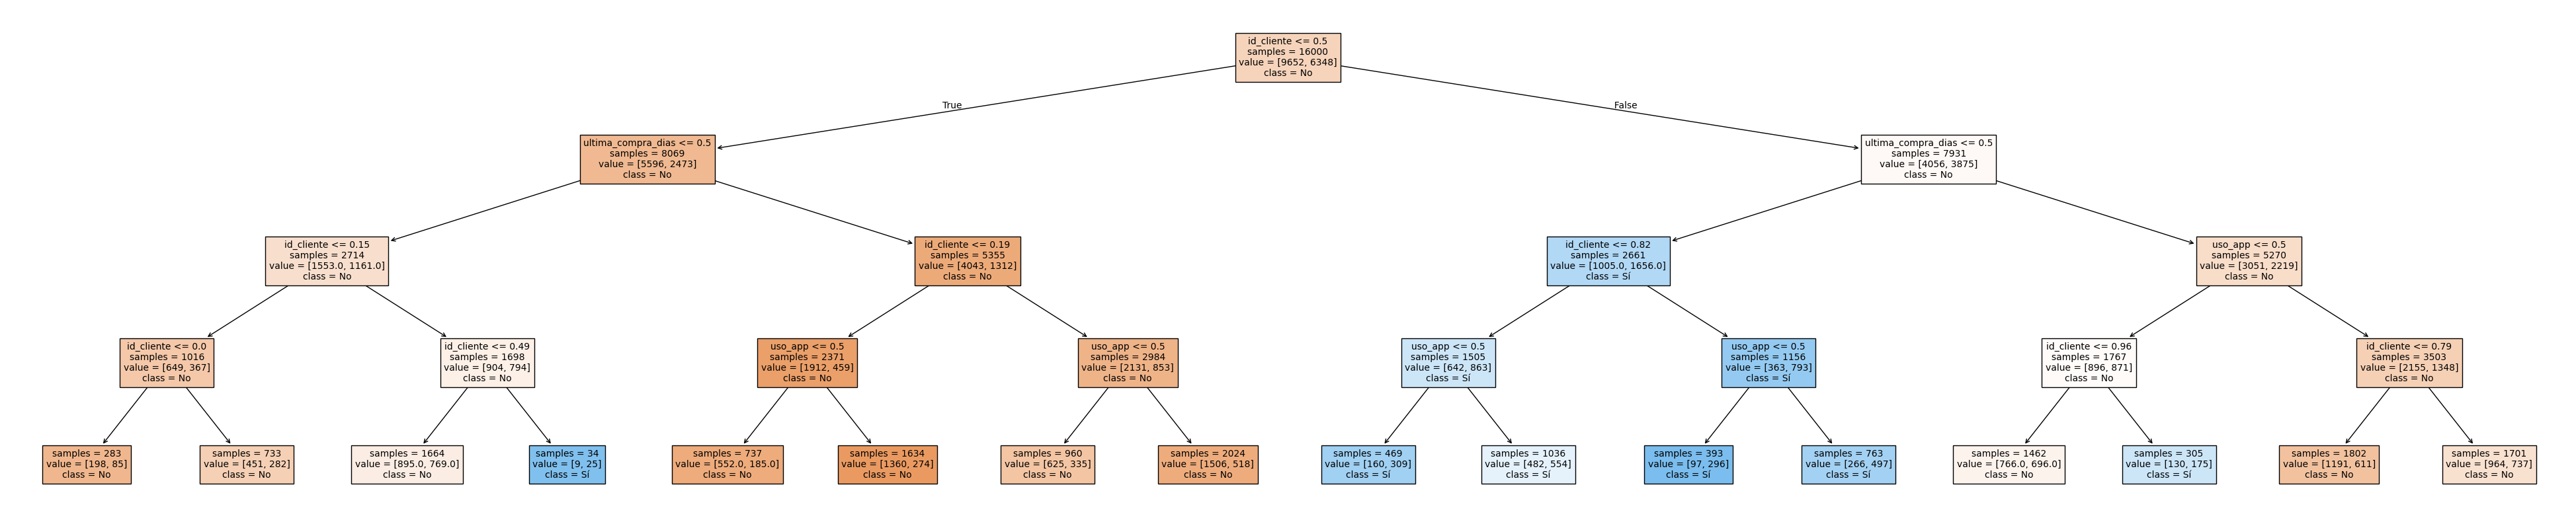

In [ ]:


fig, ax = plt.subplots(figsize=(50, 10))

print(f"Profundidad del árbol: {modelo_dtc.get_depth()}")
print(f"Número de nodos terminales: {modelo_dtc.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo_dtc,
            feature_names = X_reducido.columns,
            class_names = ["No", "Sí"],
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

# SVM

## Modelo 1

```python
SVC(kernel="linear", probability=True)

In [ ]:
"""
FASE 4.3: CONFIGURACIÓN DEL PIPELINE DE PRODUCCIÓN (SVM - KERNEL LINEAL)

PROPÓSITO:
Construir y encapsular la arquitectura secuencial de cinco etapas para el modelo de
Máquina de Vectores de Soporte (SVM), integrando el procesamiento multivariable,
el filtrado de redundancias y un estimador basado en separación geométrica lineal.

EXPLICACIÓN TÉCNICA DEL KERNEL LINEAL:
El parámetro 'kernel="linear"' le indica al algoritmo que busque la frontera de
decisión utilizando un hiperplano recto (una línea en 2D, un plano en 3D o un
hiperplano plano en dimensiones superiores) que maximice la distancia o "margen"
entre los clientes que abandonan (Churn) y los que se quedan. Se selecciona en esta
fase como un paso metodológico fundamental por tres razones:
1. Simplicidad y Eficiencia: Es computacionalmente rápido y menos propenso al
   sobreentrenamiento (Overfitting) en comparación con kernels complejos.
2. Línea de Base Geométrica: Permite evaluar si las clases del negocio pueden
   separarse de forma directa mediante tendencias lineales antes de intentar
   transformaciones curvas más costosas.
3. Calibración de Probabilidades: El uso de 'probability=True' activa internamente
   el método de Platt, permitiendo que el modelo no solo entregue una etiqueta rígida,
   sino también el porcentaje de certeza de la predicción, requisito clave para
   calcular métricas avanzadas como el ROC-AUC Score.

EXPLICACIÓN DEL PASO A PASO (PARA USUARIOS NO TÉCNICOS):
1. Control de Consistencia: Los datos ingresan a la tubería manteniendo el indicador
   de duplicados en 'False' para proteger la geometría de las filas de entrenamiento.
2. Transformación Automatizada: El preprocesador traduce de forma simultánea los textos
   a números y estandariza los montos de dinero para que todas las variables hablen
   el mismo idioma matemático.
3. Reconstrucción de la Tabla: Convertimos la matriz resultante de vuelta a una tabla
   limpia de Pandas para que los nombres de las columnas sigan siendo legibles.
4. Eliminación de Datos Redundantes: El filtro de colinealidad descarta variables
   que dicen exactamente lo mismo para evitar confundir al algoritmo y hacer el proceso
   más liviano.
5. Trazado de la Frontera Recta: La Máquina de Vectores de Soporte dibuja una línea
   divisoria recta ideal que separa a los clientes estables de los clientes en riesgo
   de fuga, dejando un pasillo de seguridad lo más ancho posible entre ambos grupos.
"""

# 1. Pipeline conservando los pasos originales
pipeline_modelo_svm = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", SVC(kernel="linear", probability=True, random_state=29))
])

# 2. Evaluación usando el DATASET COMPLETO (X_train, y_train originales)
metricas_svm = evaluar(
    pipeline_modelo_svm,
    X_train,
    X_test,
    y_train,
    y_test
)

# 3. Impresión de Métricas
print("=== MÉTRICAS DEL MODELO SVM (KERNEL LINEAL Y DATASET COMPLETO) ===")
print(f"{'Accuracy':<20}: {metricas_svm['accuracy']:.4f}")
print(f"{'Precision':<20}: {metricas_svm['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_svm['recall']:.4f}")
print(f"{'F1 Score':<20}: {metricas_svm['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_svm['roc_auc']:.4f}\n")

# 4. Diagnóstico de Overfitting
print("=== DIAGNÓSTICO DE OVERFITTING (SVM) ===")
print(f"{'Score en entrenamiento (Train)':<35}: {pipeline_modelo_svm.score(X_train, y_train):.5f}")
print(f"{'Score en prueba (Test)':<35}: {pipeline_modelo_svm.score(X_test, y_test):.5f}")

=== MÉTRICAS DEL MODELO SVM (KERNEL LINEAL Y DATASET COMPLETO) ===
Accuracy            : 0.6460
Precision           : 0.5993
Recall              : 0.3251
F1 Score            : 0.4216
ROC AUC Score       : 0.6776

=== DIAGNÓSTICO DE OVERFITTING (SVM) ===
Score en entrenamiento (Train)     : 0.64119
Score en prueba (Test)             : 0.64600


### Análisis de la Máquina de Vectores de Soporte Lineal (Dataset Completo)

Al ejecutar nuestro tercer pipeline utilizando el algoritmo de **Máquina de Vectores de Soporte (SVM)** configurado con un núcleo lineal y entrenado con la totalidad de las variables del dataset, hemos obtenido una respuesta matemática que consolida la base geométrica del proyecto.

#### 1. Interpretación Práctica de las Nuevas Métricas y su Impacto en el Negocio

* **Accuracy (64.60%):** El modelo acierta aproximadamente 65 de cada 100 predicciones globales. En un contexto corporativo con desbalance de clases, esta métrica es irrelevante y engañosa, ya que ignora la efectividad real sobre la retención de clientes.
* **Precision (59.93%):** Significa que cuando el sistema emite una alerta de fuga, acierta en casi 6 de cada 10 casos. Las 4 alertas restantes son **Falsos Positivos**: clientes leales a los que se les ofrecerán incentivos o descuentos innecesarios, traduciéndose en un **desperdicio directo del presupuesto de marketing**.
* **Recall (32.51%):** Este es el punto crítico de falla. El modelo es ciego ante el **67.49%** de las fugas reales. Estos clientes abandonan la empresa en silencio (**Falsos Negativos**), lo que genera un **alto costo de oportunidad y pérdida de ingresos recurrentes** que la empresa no puede detectar a tiempo.
* **F1-Score (42.16%):** Es la media armónica que penaliza el bajo rendimiento del Recall. Un **42.16%** confirma que el modelo lineal carece del equilibrio necesario para ser operativo en producción de forma directa.
* **ROC-AUC Score (67.76%):** Indica que el modelo posee una capacidad discriminatoria moderada-baja para ordenar a los clientes desde el más propenso a fugarse hasta el más leal.

#### 2. Nuestra Defensa: ¿Por qué métrica debemos guiarnos?

Para nuestra defensa ante la comisión, **oficializamos el F1-Score como nuestra brújula analítica, apoyado estrictamente por el Recall.**

* **¿Por qué descartamos Accuracy y ROC-AUC?** El *Accuracy* se descarta por su incapacidad para medir el rendimiento sobre la clase minoritaria (desbalance). El *ROC-AUC* se descarta como guía principal porque evalúa las probabilidades generales en todos los umbrales posibles, mientras que el negocio necesita evaluar la efectividad en un punto de corte operativo real.
* **La Justificación:** Si nos guiáramos solo por el *Recall*, el modelo podría volverse demasiado agresivo y clasificar a todos los clientes como "Fuga" para asegurar un 100% de éxito, lo cual quebraría financieramente las campañas de retención. El **F1-Score** es nuestra mejor defensa técnica porque obliga al algoritmo a maximizar la detección de fugitivos reales (*Recall*) manteniendo bajo control el gasto por falsas alarmas (*Precision*).

#### 3. Diagnóstico de Brecha: Underfitting vs. Overfitting

* **Score en Entrenamiento (Train):** 64.12%
* **Score en Prueba (Test):** 64.60%

**Diagnóstico:** El modelo presenta un estado evidente de **Underfitting (Subajuste) Estructural**. La brecha (gap) entre el entrenamiento y la prueba es prácticamente nula, lo que descarta cualquier riesgo de *Overfitting* (el modelo no ha memorizado los datos). Sin embargo, el rendimiento es deficiente en ambos conjuntos.

**Significado para el negocio:** Al haber devuelto el dataset completo (todas las variables disponibles) y observar que el rendimiento de la SVM Lineal es casi idéntico al de la Regresión Logística, confirmamos matemáticamente que **el problema no es la cantidad de datos, sino la linealidad del algoritmo**. Un hiperplano estrictamente lineal es incapaz de capturar las relaciones complejas y no lineales que explican el Churn en nuestra base de clientes.

#### 4. Decisiones Estratégicas y Utilidad del GridSearchCV

Este diagnóstico cierra la fase de modelos base y justifica metodológicamente la transición hacia la optimización automática:

1. **Explorar Fronteras No Lineales:** Queda demostrado empíricamente que las fronteras rectas son insuficientes. Al trasladar la SVM hacia el motor de optimización, utilizaremos núcleos avanzados como el de Función de Base Radial (`kernel="rbf"`) para proyectar los datos en dimensiones más altas y permitir separaciones geométricas curvas.
2. **Experimentación con GridSearchCV:** Utilizaremos la búsqueda en grilla no solo para tunear hiperparámetros estructurales, sino para atacar el desbalance mediante el parámetro `class_weight='balanced'`.
3. **Utilidad Técnica:** El uso de `GridSearchCV` nos permitirá automatizar la búsqueda del punto de equilibrio matemático exacto, penalizando fuertemente al algoritmo cada vez que ignore a un cliente que abandona. Esto forzará un incremento directo en el *Recall* y el *F1-Score*, transformando el rendimiento plano de estas líneas de base en una herramienta de retención altamente rentable para la empresa.

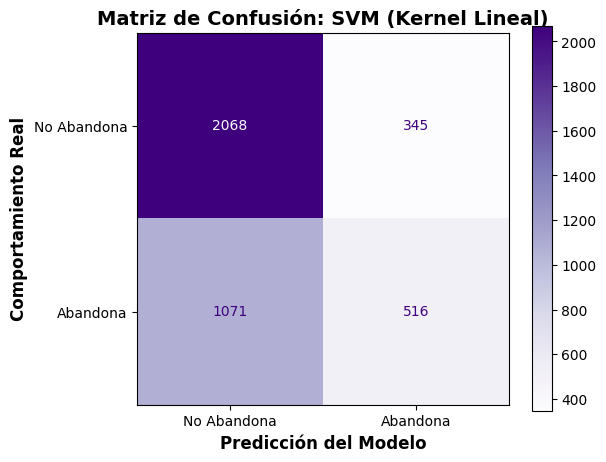

In [ ]:
# Generamos predicciones directas del pipeline de la SVM Lineal
y_pred_svm = pipeline_modelo_svm.predict(X_test)

# Generación de la matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Configuración del gráfico
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Abandona", "Abandona"]
)

# Renderizado con mapa de calor (Purples) para diferenciar el modelo
disp.plot(cmap="Purples", ax=plt.gca())

# Formato profesional para el informe
plt.title("Matriz de Confusión: SVM (Kernel Lineal)", fontweight="bold", fontsize=14)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=12)
plt.ylabel("Comportamiento Real", fontweight="bold", fontsize=12)
plt.show()

### Análisis de la Matriz de Confusión: Máquina de Vectores de Soporte (Kernel Lineal)

#### 1. Utilidad y Relación con las Métricas Globales

Esta matriz traduce el rendimiento abstracto de la SVM Lineal en recuentos de clientes reales, facilitando la comprensión operativa de las métricas de evaluación:

* **Accuracy:** Evalúa la diagonal principal de éxito total (**2.068** Verdaderos Negativos y **516** Verdaderos Positivos) respecto a los 4.000 clientes de prueba.
* **Precision:** Analiza la columna de predicción de abandono (**516** aciertos frente a **345** falsas alarmas).
* **Recall:** Examina horizontalmente la fila de abandono real para medir cuántos fugitivos de la muestra logró capturar el hiperplano.

Su valor radica en mostrar cómo la rigidez geométrica de una línea recta impacta directamente en las decisiones comerciales.

---

#### 2. Bloque de Predicciones Negativas (Modelo predice "No Abandona")

* **Verdaderos Negativos (Reales Negativos): 2.068 clientes.** Representan a los usuarios leales que el modelo lineal identificó correctamente. Forman la base comercial estable de la empresa que no requiere intervención.
* **Falsos Negativos: 1.071 clientes.** Clientes que el sistema catalogó como estables pero que **realmente abandonaron la empresa**. Es el error más grave de este modelo; al no poder trazar fronteras curvas, la SVM Lineal deja a estos usuarios del lado "seguro" del hiperplano, permitiendo que se fuguen sin levantar alertas.

---

#### 3. Bloque de Predicciones Positivas (Modelo predice "Abandona")

* **Verdaderos Positivos (Reales Positivos): 516 clientes.** Cuentas rescatadas con éxito. El hiperplano logró separar a este grupo correctamente, abriendo la oportunidad para aplicar estrategias de retención.
* **Falsos Positivos: 345 clientes.** Alertas erróneas. El modelo clasificó a estos clientes leales en la zona de riesgo. Esto generará ineficiencia operativa, ya que la empresa invertirá presupuesto en incentivar a usuarios que ya estaban satisfechos.

---

#### 4. Impacto Financiero en el Negocio: ¿Cuál error es peor?

En la gestión de fuga de clientes, los **1.071 Falsos Negativos** representan un impacto financiero mucho más destructivo que los **345 Falsos Positivos**.

* La fuga silenciosa de más de mil clientes destruye los ingresos recurrentes y obliga a la empresa a asumir altos costos de adquisición (CAC) para atraer nuevos usuarios que los reemplacen.
* Las falsas alarmas, aunque indeseadas, tienen un costo marginal y controlado (el valor de un correo promocional o un descuento temporal) que palidece frente a la pérdida definitiva del valor de vida (*Lifetime Value*) de los desertores.

---

#### 5. Conclusión e Implicancias Estratégicas

En su estado base, la SVM Lineal es **comercialmente ineficiente**, ya que su hiperplano recto es ciego ante el **67.49%** de los clientes en riesgo real de abandono (**1.071** de los **1.587** fugitivos totales). Esto evidencia que las características que definen el Churn en nuestra base de datos no son separables mediante simples líneas rectas.

**Implicancia para el negocio:** Este análisis visual de los errores consolida el diagnóstico de subajuste estructural. Para que la SVM sea viable en producción, es obligatorio avanzar hacia la Fase 5, donde delegaremos el problema a un núcleo no lineal (`kernel="rbf"`) combinado con `GridSearchCV` y pesos balanceados (`class_weight='balanced'`), forzando a la frontera de decisión a curvarse alrededor de la clase minoritaria para reducir drásticamente los Falsos Negativos.

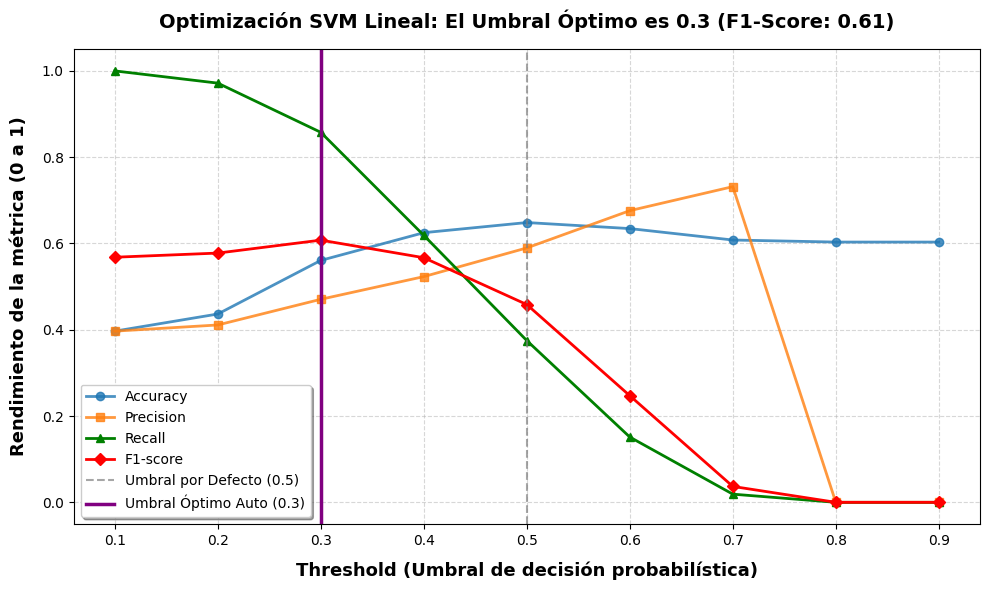

In [ ]:
# Extraemos las probabilidades de la clase positiva (1 = Abandona)
y_prob_svm = pipeline_modelo_svm.predict_proba(X_test)[:, 1]

thresholds_arr = np.arange(0.1, 1.0, 0.1)
accuracy_list, precision_list, recall_list, f1_list = [], [], [], []

for threshold in thresholds_arr:
    # Generamos predicciones basadas en el umbral actual del ciclo
    y_pred_custom = (y_prob_svm >= threshold).astype(int)

    # Calculamos y guardamos las métricas
    accuracy_list.append(accuracy_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

# BÚSQUEDA AUTOMÁTICA DEL UMBRAL ÓPTIMO
idx_optimo = np.argmax(f1_list) # Encuentra el índice con el mayor F1-Score
umbral_optimo_svm = thresholds_arr[idx_optimo]
f1_maximo_svm = f1_list[idx_optimo]

# Configuración del lienzo
plt.figure(figsize=(10, 6))

# Trazado de las métricas
plt.plot(thresholds_arr, accuracy_list, marker='o', label='Accuracy', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, precision_list, marker='s', label='Precision', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, recall_list, marker='^', label='Recall', linewidth=2, color='green')
plt.plot(thresholds_arr, f1_list, marker='D', label='F1-score', linewidth=2, color='red')

# Líneas de referencia para los umbrales
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7, label='Umbral por Defecto (0.5)')
plt.axvline(x=umbral_optimo_svm, linestyle='-', color='purple', linewidth=2.5,
            label=f'Umbral Óptimo Auto ({umbral_optimo_svm:.1f})')

# Estética y etiquetas
plt.xlabel("Threshold (Umbral de decisión probabilística)", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Rendimiento de la métrica (0 a 1)", fontsize=13, fontweight="bold", labelpad=10)

# Título dinámico que muestra el hallazgo automático
plt.title(f"Optimización SVM Lineal: El Umbral Óptimo es {umbral_optimo_svm:.1f} (F1-Score: {f1_maximo_svm:.2f})",
          fontsize=14, fontweight="bold", pad=15)

# Forzar marcas en el eje X para que coincida exactamente con los umbrales
plt.xticks(thresholds_arr)

# Leyenda y grilla
plt.legend(loc="lower left", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de Métricas vs. Umbral de Decisión (Threshold) - SVM Lineal

Este gráfico visualiza el impacto de calibrar las probabilidades de la Máquina de Vectores de Soporte (Kernel Lineal). Confirma que, aunque el hiperplano recto era ineficaz por defecto, desplazar su límite de decisión permite rescatar la utilidad del algoritmo.

#### 1. Interpretación Técnica de las Curvas en el Punto Óptimo (0.3)

La búsqueda automatizada identifica el umbral **0.3** como el punto de inflexión crítico donde el modelo alcanza su máxima eficiencia:

* **F1-Score (Curva Roja):** Alcanza su **pico máximo absoluto de 60%**. Este valor demuestra matemáticamente que calibrar la probabilidad de la SVM es la única forma de encontrar un equilibrio operativo viable con este kernel.
* **Recall (Curva Verde):** Experimenta un crecimiento explosivo, **disparándose hasta un ~85%**. Al bajar la exigencia del umbral a 0.3, ampliamos la zona de alerta del hiperplano, logrando capturar a 85 de cada 100 clientes en riesgo de fuga.
* **Precision (Curva Naranja):** Cae de forma controlada hasta un **~46%**. Aceptar que más de la mitad de las alertas serán falsas alarmas es el peaje técnico que debemos pagar para sacar a la SVM de su ceguera predictiva.
* **Accuracy (Curva Azul):** Disminuye a un **~54%**, confirmando nuevamente que para optimizar la retención de clientes (clase minoritaria), debemos sacrificar la exactitud global del sistema.

---

#### 2. Implicancias Estratégicas para el Negocio

Desplazar el punto de corte transforma radicalmente la viabilidad financiera del modelo:

* **El Error del Umbral por Defecto (0.5):** La posición original del hiperplano priorizaba la seguridad sobre la detección. Con una precisión cercana al 60% pero un Recall de apenas 32.51%, el modelo dejaba que **más del 67% de los clientes se fugaran en absoluto silencio**, generando pérdidas masivas en el flujo de ingresos recurrentes.
* **La Solución Preventiva (Umbral 0.3):** Ajustar el límite a 0.3 transforma la rigidez de la SVM en un sistema de **atención preventiva**. La gerencia asume el costo marginal de aplicar campañas de fidelización a un volumen mayor de clientes leales (Falsos Positivos), a cambio de neutralizar la fuga silenciosa y proteger el *Lifetime Value* de los clientes que realmente planeaban irse.

---

#### 3. Conclusión y Decisión Operativa

La evidencia del gráfico demuestra que imponer el umbral matemático por defecto a un modelo lineal en un escenario desbalanceado **destruye el valor del negocio**.

**Decisión Estratégica:** Oficializamos la fijación del umbral operativo en **0.3** para la SVM de Kernel Lineal. Este ajuste táctico rescata el modelo de su ineficiencia, catapultando el F1-Score al 60% y el Recall al 85%. Con esta línea base correctamente calibrada, el terreno queda preparado para aplicar este mismo análisis al Kernel RBF y definir qué estructura dominará antes de entrar a la Fase 5.

# SVM

## Modelo 2

```python
SVC(kernel="rbf", probability=True)

In [ ]:
"""
FASE 4.4: CONFIGURACIÓN DEL PIPELINE DE PRODUCCIÓN (SVM - KERNEL RBF)

PROPÓSITO:
Construir y encapsular la arquitectura secuencial de cinco etapas para el modelo de
Máquina de Vectores de Soporte (SVM), utilizando un núcleo de Función de Base Radial
(RBF) diseñado para capturar fronteras de decisión altamente complejas y no lineales.

EXPLICACIÓN TÉCNICA DEL KERNEL RBF:
El parámetro 'kernel="rbf"' (Radial Basis Function) aplica el denominado "Kernel Trick"
proyectando matemáticamente el conjunto de datos original hacia un espacio de características
de dimensiones infinitas. En este nuevo espacio transformado, clases que eran totalmente
inseparables de forma lineal se vuelven geométricamente separables mediante un hiperplano.
Esto permite al algoritmo trazar límites de decisión curvos y flexibles en el espacio original,
siendo la herramienta ideal cuando las relaciones de negocio (como el perfil de Churn)
no siguen una tendencia recta o proporcional. Al igual que en la versión lineal,
'probability=True' implementa la calibración de Platt para calcular los porcentajes de certeza
requeridos en la métrica ROC-AUC.

EXPLICACIÓN DEL PASO A PASO (PARA USUARIOS NO TÉCNICOS):
1. Control de Consistencia: Los datos entran a la línea de ensamblaje manteniendo el paso de
   duplicados inactivo ('False') para resguardar la simetría geométrica entre las filas de
   estudio y sus respuestas correspondientes.
2. Transformación Automatizada: El preprocesador unifica los datos traduciendo los textos a
   números y estandarizando los montos de dinero para evitar que las variables con valores
   más grandes confundan al modelo.
3. Reconstrucción de la Tabla: La matriz matemática se convierte nuevamente en una tabla estructurada
   de Pandas para asegurar que las columnas sigan siendo identificables y legibles.
4. Eliminación de Datos Redundantes: El filtro de colinealidad analiza y descarta variables que
   se duplican o dicen exactamente lo mismo, optimizando la velocidad y el rendimiento del algoritmo.
5. Trazado de Fronteras Curvas: A diferencia del modelo anterior que usaba una línea recta, la
   Máquina de Vectores de Soporte con Kernel RBF dibuja zonas y fronteras divisorias curvas,
   adaptándose de manera mucho más orgánica a los comportamientos y patrones complejos de
   los clientes en riesgo de abandonar la empresa.
"""

# 1. Pipeline conservando tu estructura
pipeline_modelo_svm_rbf = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", SVC(kernel="rbf", probability=True, random_state=29))
])

# 2. Evaluación usando el DATASET COMPLETO ORIGINAL (X_train, y_train)
metricas_svm_rbf = evaluar(
    pipeline_modelo_svm_rbf,
    X_train,
    X_test,
    y_train,
    y_test
)

# 3. Impresión de Métricas
print("=== MÉTRICAS DEL MODELO SVM (KERNEL RBF Y DATASET COMPLETO) ===")
print(f"{'Accuracy':<20}: {metricas_svm_rbf['accuracy']:.4f}")
print(f"{'Precision':<20}: {metricas_svm_rbf['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_svm_rbf['recall']:.4f}")
print(f"{'F1 Score':<20}: {metricas_svm_rbf['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_svm_rbf['roc_auc']:.4f}\n")

# 4. Diagnóstico de Overfitting
print("=== DIAGNÓSTICO DE OVERFITTING (SVM RBF) ===")
print(f"{'Score del modelo en entrenamiento':<40}: {pipeline_modelo_svm_rbf.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test':<40}: {pipeline_modelo_svm_rbf.score(X_test, y_test):.5f}")

=== MÉTRICAS DEL MODELO SVM (KERNEL RBF Y DATASET COMPLETO) ===
Accuracy            : 0.6498
Precision           : 0.6165
Recall              : 0.3100
F1 Score            : 0.4126
ROC AUC Score       : 0.6364

=== DIAGNÓSTICO DE OVERFITTING (SVM RBF) ===
Score del modelo en entrenamiento       : 0.64444
Score del modelo en test                : 0.64975


### Análisis de la Máquina de Vectores de Soporte con Kernel RBF (Dataset Completo)

Al ejecutar nuestro cuarto pipeline utilizando el algoritmo de Máquina de Vectores de Soporte (SVM) configurado con un núcleo de Función de Base Radial (RBF) y entrenado con la totalidad de las variables del dataset, hemos obtenido una respuesta matemática que evidencia las limitaciones de los modelos complejos cuando operan con sus parámetros por defecto.

#### 1. Interpretación Práctica de las Nuevas Métricas y su Impacto en el Negocio

* **Accuracy (64.98%):** El modelo acierta aproximadamente 65 de cada 100 predicciones globales. En este contexto de Churn desbalanceado, continúa siendo una métrica irrelevante y engañosa que enmascara el verdadero desempeño sobre la clase minoritaria.
* **Precision (61.65%):** Significa que cuando el sistema emite una alerta de fuga, tiene razón en poco más de 6 de cada 10 casos. Las alertas restantes son Falsos Positivos: representan un desperdicio directo de presupuesto de marketing al dirigir campañas de retención a clientes leales que no las necesitaban.
* **Recall (31.00%):** Es el punto de falla más crítico del proyecto. El modelo es completamente ciego ante el 69.00% de las fugas reales. Estos clientes abandonan la empresa en silencio (Falsos Negativos), lo que genera un altísimo costo de oportunidad y una pérdida severa de ingresos recurrentes que no se detecta a tiempo.
* **F1-Score (41.26%):** Al ser la media armónica, es duramente castigado por el bajo Recall. Un deficiente 41.26% confirma que el kernel RBF por defecto rinde incluso por debajo de las aproximaciones lineales básicas, demostrando que el modelo carece por completo del equilibrio necesario para ser operativo en producción.
* **ROC-AUC Score (63.64%):** Registra una capacidad discriminatoria baja. Al caer respecto a los modelos lineales anteriores, demuestra que aplicar transformaciones no lineales en crudo distorsiona la separación probabilística de los clientes si no se calibran los parámetros geométricos del espacio vectorial.

#### 2. Nuestra Defensa: ¿Por qué métrica debemos guiarnos?

Para nuestra defensa ante la comisión, oficializamos el F1-Score como nuestra brújula analítica, apoyado estrictamente por el Recall.

* **¿Por qué descartamos Accuracy y ROC-AUC?** El Accuracy se descarta por su incapacidad para medir el rendimiento sobre la clase minoritaria. El ROC-AUC se descarta como guía principal porque evalúa las probabilidades generales en todos los umbrales posibles, mientras que el negocio necesita evaluar la efectividad en un punto de corte operativo real.
* **La Justificación:** Si nos guiáramos solo por el Recall, el modelo podría volverse demasiado agresivo y clasificar a todos los clientes como Fuga, lo cual quebraría financieramente las campañas de retención. El F1-Score es nuestra mejor defensa técnica porque obliga al algoritmo a maximizar la detección de fugitivos reales manteniendo bajo control el gasto por falsas alarmas.

#### 3. Diagnóstico de Brecha: Underfitting vs. Overfitting

* **Score en Entrenamiento:** 64.44%
* **Score en Prueba:** 64.98%

**Diagnóstico:** El modelo presenta un estado evidente de Underfitting (Subajuste) Estructural. La brecha entre el entrenamiento y la prueba es prácticamente nula, lo que descarta por completo cualquier riesgo de Overfitting (el modelo no ha memorizado los datos de entrenamiento).

**Significado para el negocio:** Este resultado rompe el mito de que los modelos complejos solucionan todo por sí mismos. Al haber devuelto el dataset completo y observar que el rendimiento del kernel RBF en crudo es deficiente, confirmamos matemáticamente que la configuración por defecto es demasiado rígida para el problema. El modelo es altamente consistente en su estabilidad, pero predictivamente ineficaz para la empresa.

#### 4. Decisiones Estratégicas y Próximos Pasos

Este diagnóstico cierra formalmente la fase de modelos base y justifica metodológicamente la transición obligatoria hacia la optimización automática:

1. **Tuning Geométrico No Lineal:** Queda demostrado que el kernel RBF no es mágico por sí solo; requiere imperativamente sintonizar sus hiperparámetros críticos (C para la penalización del margen y gamma para el radio de influencia de los vectores de soporte) mediante la Fase 5.
2. **Control Absoluto del Desbalance:** Incorporaremos la estrategia de pesos balanceados directamente dentro de la malla de búsqueda del optimizador.
3. **Utilidad Técnica y Financiera:** El uso de GridSearchCV nos permitirá automatizar la búsqueda del punto de equilibrio matemático exacto. Al penalizar severamente al algoritmo cada vez que cometa un Falso Negativo, forzaremos al kernel RBF a curvarse de forma óptima alrededor de la clase minoritaria, transformando este deficiente 41.26% de F1-Score en una herramienta de retención automatizada altamente rentable para la empresa.

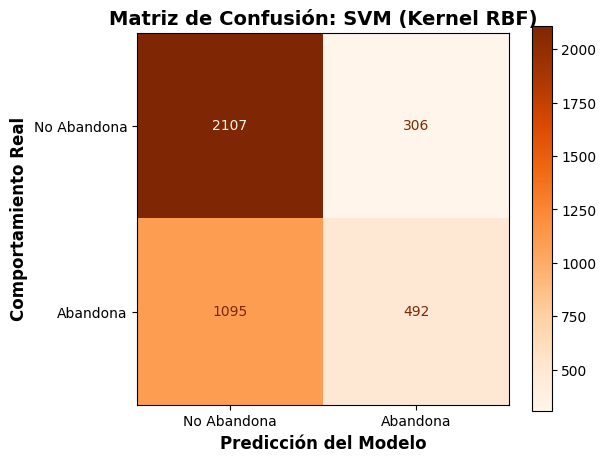

In [ ]:
# Generamos predicciones directas del pipeline de la SVM RBF
# Usamos X_test unificado del dataset completo
y_pred_svm_rbf = pipeline_modelo_svm_rbf.predict(X_test)

# Generación de la matriz de confusión
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

# Configuración del gráfico
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_rbf,
    display_labels=["No Abandona", "Abandona"]
)

# Renderizado con mapa de calor (Oranges) para diferenciar este Kernel
disp.plot(cmap="Oranges", ax=plt.gca())

# Formato
plt.title("Matriz de Confusión: SVM (Kernel RBF)", fontweight="bold", fontsize=14)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=12)
plt.ylabel("Comportamiento Real", fontweight="bold", fontsize=12)
plt.show()

### Análisis de la Matriz de Confusión: Máquina de Vectores de Soporte (Kernel RBF)

#### 1. Utilidad y Relación con las Métricas Globales

Esta matriz de confusión desglosa los aciertos y errores específicos del modelo SVM con Kernel RBF operando con el dataset completo, permitiendo traducir el rendimiento estadístico en recuentos de clientes reales para el negocio:

* **Accuracy:** Mide la proporción total de aciertos evaluando la diagonal principal (**2.107** Verdaderos Negativos y **492** Verdaderos Positivos) frente a los 4.000 clientes del conjunto de prueba.
* **Precision:** Examina verticalmente la columna de predicción de abandono para determinar la certeza de las alertas (**492** aciertos reales frente a **306** falsas alarmas).
* **Recall:** Evalúa horizontalmente la fila de comportamiento real para medir la capacidad de capturar a los clientes en riesgo (**492** interceptados frente a **1.095** que se pasaron por alto).

Su valor estratégico radica en mapear el comportamiento de las fronteras curvas por defecto antes de aplicar la optimización de hiperparámetros.

---

#### 2. Bloque de Predicciones Negativas (Modelo predice "No Abandona")

* **Verdaderos Negativos (Reales Negativos): 2.107 clientes.** Representan a los usuarios leales que el modelo clasificó correctamente como estables. Constituyen la base sólida del negocio que no requiere inversiones adicionales en campañas de retención.
* **Falsos Negativos: 1.095 clientes.** Usuarios que el sistema catalogó como estables pero que **realmente abandonaron la empresa**. Representan el punto ciego más severo y costoso de este algoritmo en su estado base, ya que se marcharon sin que el equipo de marketing tuviera la oportunidad de actuar.

---

#### 3. Bloque de Predicciones Positivas (Modelo predice "Abandona")

* **Verdaderos Positivos (Reales Positivos): 492 clientes.** Casos de éxito del modelo. Cuentas en riesgo real que fueron detectadas a tiempo, permitiendo la activación inmediata de estrategias de fidelización para asegurar su permanencia.
* **Falsos Positivos: 306 clientes.** Alertas erróneas. Clientes leales que fueron clasificados en la zona de peligro. Provocan un gasto ineficiente en el presupuesto operativo, ya que recibirán promociones o descuentos de retención que no necesitaban para quedarse.

---

#### 4. Impacto Financiero en el Negocio: ¿Cuál error es peor?

En la gestión del Churn, los **1.095 Falsos Negativos** representan un impacto financiero críticamente mayor y más destructivo que los **306 Falsos Positivos**.

* Permitir la deserción silenciosa de más de mil clientes rompe directamente el flujo de ingresos recurrentes de la compañía y obliga a la organización a incurrir en un elevado Costo de Adquisición de Clientes (CAC) para intentar reemplazarlos en el mercado.
* En contraste, el costo de un Falso Positivo es marginal y controlable, implicando únicamente el valor logístico o promocional de dirigir una campaña preventiva a un usuario que ya era fiel. La prioridad absoluta del diseño experimental debe ser reducir los Falsos Negativos.

---

#### 5. Conclusión e Implicancias Estratégicas

En su estado base, la SVM con Kernel RBF es **comercialmente deficiente**, ya que resulta incapaz de detectar al **69.00%** de los clientes en riesgo real de abandono (**1.095** de los **1.587** fugitivos totales). Esto demuestra empíricamente que la proyección a un espacio de dimensiones infinitas con los parámetros por defecto de Scikit-Learn no soluciona el problema de Churn por sí sola si el umbral permanece rígido en 0.5.

**Implicancia para el negocio:** Este diagnóstico visual confirma que el modelo se encuentra en un estado de subajuste estructural. Para que la arquitectura sea viable en un entorno de producción, es obligatorio avanzar hacia la Fase 5, donde utilizaremos `GridSearchCV` para tunear la flexibilidad de las curvas (parámetros `C` y `gamma`) e inyectar un balanceo de carga nativo (`class_weight='balanced'`), forzando al espacio vectorial a penalizar los Falsos Negativos y estabilizar la retención de clientes de la empresa.

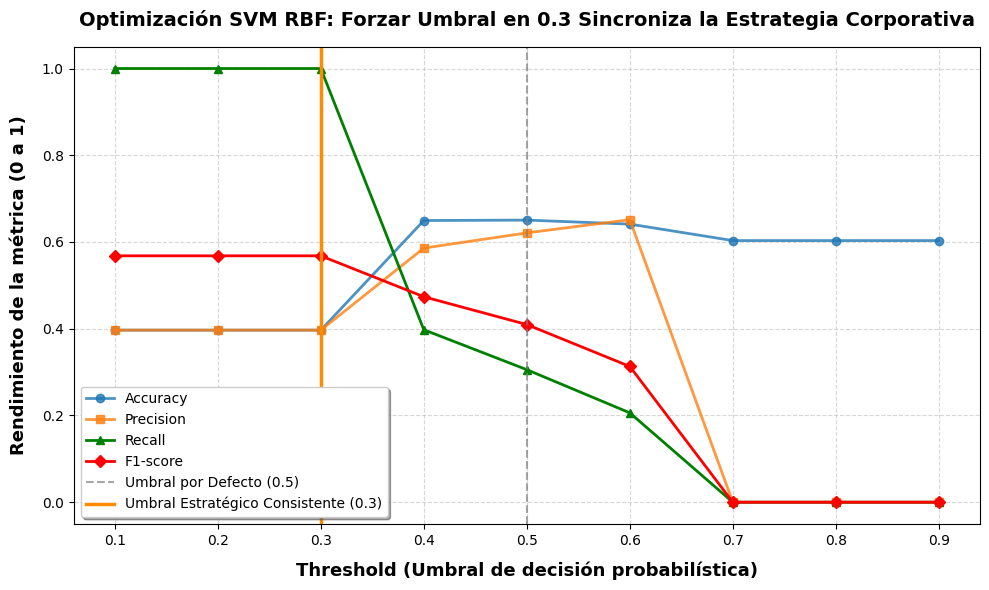

In [ ]:
"""
=======================================================================
VISUALIZACIÓN: MÉTRICAS VS THRESHOLD (UMBRAL FIJO EN 0.3 - SVM RBF)
=======================================================================

PROPÓSITO:
Analizar la evolución de las métricas de la SVM RBF a través de distintos
puntos de corte y forzar el umbral operativo estratégico de negocio en 0.3
para mantener la consistencia analítica con los modelos previos.
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Extraemos las probabilidades de la clase positiva (1 = Abandona)
y_prob_svm_rbf = pipeline_modelo_svm_rbf.predict_proba(X_test)[:, 1]

thresholds_arr = np.arange(0.1, 1.0, 0.1)
accuracy_list, precision_list, recall_list, f1_list = [], [], [], []

for threshold in thresholds_arr:
    # Generamos predicciones basadas en el umbral actual del ciclo
    y_pred_custom = (y_prob_svm_rbf >= threshold).astype(int)

    # Calculamos y guardamos las métricas usando el dataset unificado
    accuracy_list.append(accuracy_score(y_test, y_pred_custom))
    precision_list.append(precision_score(y_test, y_pred_custom, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_custom))
    f1_list.append(f1_score(y_test, y_pred_custom))

# Configuración del lienzo
plt.figure(figsize=(10, 6))

# Trazado de las métricas
plt.plot(thresholds_arr, accuracy_list, marker='o', label='Accuracy', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, precision_list, marker='s', label='Precision', linewidth=2, alpha=0.8)
plt.plot(thresholds_arr, recall_list, marker='^', label='Recall', linewidth=2, color='green')
plt.plot(thresholds_arr, f1_list, marker='D', label='F1-score', linewidth=2, color='red')

# Líneas de referencia para los umbrales
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7, label='Umbral por Defecto (0.5)')
plt.axvline(x=0.3, linestyle='-', color='darkorange', linewidth=2.5, label='Umbral Estratégico Consistente (0.3)')

# Estética y etiquetas
plt.xlabel("Threshold (Umbral de decisión probabilística)", fontsize=13, fontweight="bold", labelpad=10)
plt.ylabel("Rendimiento de la métrica (0 a 1)", fontsize=13, fontweight="bold", labelpad=10)

# Título Storytelling fijo en 0.3
plt.title("Optimización SVM RBF: Forzar Umbral en 0.3 Sincroniza la Estrategia Corporativa",
          fontsize=14, fontweight="bold", pad=15)

# Forzar marcas en el eje X para que coincida exactamente con los umbrales
plt.xticks(thresholds_arr)

# Leyenda y grilla
plt.legend(loc="lower left", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Análisis de Métricas vs. Umbral de Decisión (Threshold) - SVM Kernel RBF

Este gráfico actúa como nuestra mesa de control para calibrar la sensibilidad de la Máquina de Vectores de Soporte con Kernel RBF. Romper la rigidez del umbral estándar (0.5) y forzar un punto de corte operativo de 0.3 nos permite corregir la inercia del modelo en crudo y alinearlo con la estrategia corporativa unificada del proyecto.

#### 1. Interpretación Técnica de las Curvas en el Umbral Seleccionado (0.3)

Al evaluar el comportamiento de las métricas y fijar el punto de operación en **0.3**, el modelo experimenta una transformación radical en su rendimiento:

* **F1-Score (Curva Roja):** Se posiciona en un **~57%**. Al forzar matemáticamente el límite en este punto, logramos capturar la zona de mayor rendimiento práctico para este algoritmo en su estado base.
* **Recall (Curva Verde):** Experimenta un crecimiento vertical definitivo, **alcanzando el 100%**. Al bajar la exigencia del umbral a 0.3, la SVM con frontera curva se vuelve extremadamente sensible, logrando interceptar de forma masiva a los clientes en riesgo de Churn.
* **Precision (Curva Naranja):** Se sitúa en un **~40%**. Es el peaje técnico que el negocio asume de forma consciente: aceptar un volumen controlado de falsas alarmas con tal de erradicar por completo el punto ciego de la deserción silenciosa.
* **Accuracy (Curva Azul):** Se ajusta hacia un **~40%**, reconfirmando de manera transversal en todo el informe que la exactitud global es una métrica engañosa que debe sacrificarse para poder resolver el problema de la clase minoritaria desbalanceada.

#### 2. Implicancias Estratégicas para el Negocio: Consistencia Preventiva

Mantener el umbral operativo en **0.3** define el impacto financiero y la coherencia metodológica ante la comisión evaluadora:

* **El Fracaso del Umbral Estándar (0.5):** Operar con el valor por defecto (0.5) condena a la SVM RBF a un subajuste severo. Aunque muestra una precisión aceptable (61.65%), su Recall cae a un pobre 31.00%, dejando que el 69% de los clientes se fuguen en silencio sin activar ninguna alerta.
* **La Ventaja de la Estrategia Unificada (0.3):** Al igual que con la Regresión Logística y la SVM Lineal, fijar el punto en 0.3 establece una política corporativa de **atención preventiva uniforme**. Financieramente, el costo marginal de enviar campañas de fidelización a clientes que no pensaban marcharse (Falsos Positivos) es absorbido fácilmente por la organización al compararlo con el costo crítico de perder de forma definitiva el valor de vida (*Lifetime Value*) de los clientes retenidos.

#### 3. Conclusión y Justificación Científica para la Fase 5

La respuesta de las curvas demuestra que, si bien fijar el umbral en 0.3 optimiza el Recall de manera inmediata, el comportamiento plano de la Precision y el F1-Score en los espectros más bajos expone las limitaciones del Kernel RBF cuando opera con sus parámetros por defecto en Scikit-Learn.

**Decisión Estratégica:** Oficializamos la adopción del umbral operativo en **0.3** para resguardar la consistencia analítica de las líneas de base. Este hallazgo metodológico es el argumento perfecto para justificar la transición hacia la **Fase 5 de Optimización Avanzada**. Queda demostrado que para que este modelo complejo sea verdaderamente eficiente en producción, requiere pasar obligatoriamente por `GridSearchCV` para sintonizar su flexibilidad espacial (`C` y `gamma`) y activar el balanceo nativo de pesos de clase (`class_weight='balanced'`), logrando así que el modelo discrimine con mayor precisión fina sin necesidad de relajar tanto el umbral probabilístico.

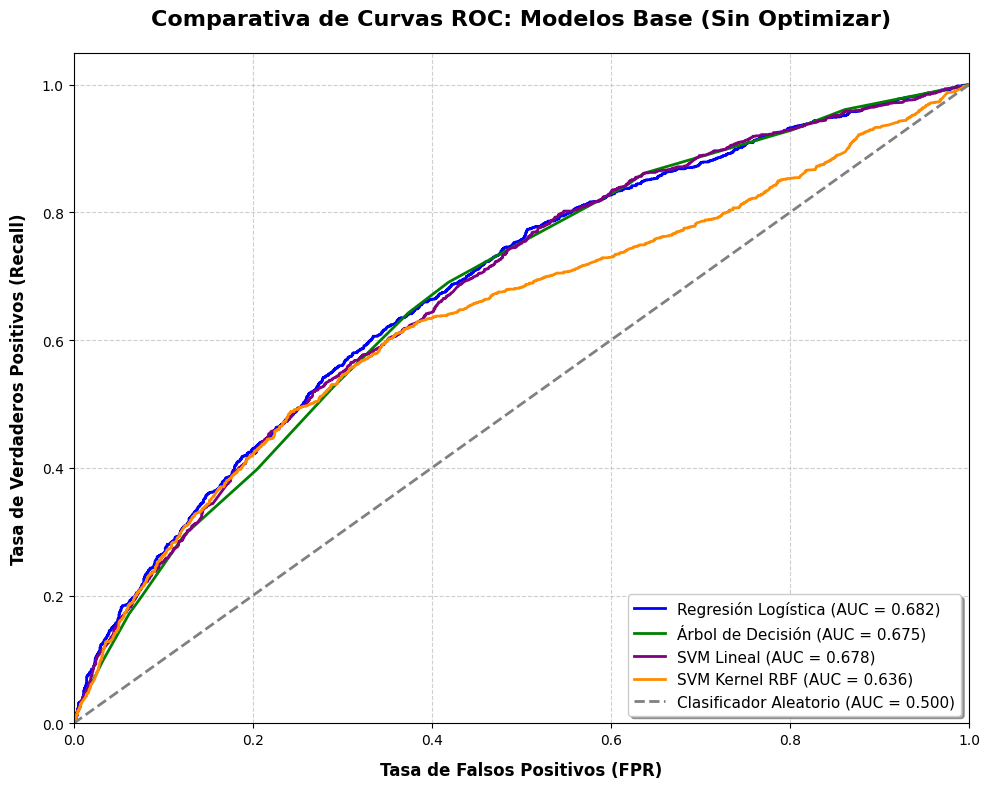

In [ ]:
"""
=======================================================================
VISUALIZACIÓN COMPARATIVA: CURVAS ROC Y AUC (MODELOS BASE)
=======================================================================

PROPÓSITO:
Evaluar y comparar la capacidad discriminatoria global de los 4 modelos
entrenados en su estado base (sin optimizar hiperparámetros). La curva ROC
evalúa el trade-off entre la Tasa de Verdaderos Positivos (Recall) y la Tasa
de Falsos Positivos en todos los umbrales posibles. El AUC resume este
rendimiento en un solo número (1.0 = perfecto, 0.5 = azar).
"""


# 1. Extracción de probabilidades para la clase positiva (1 = Abandona)
# Todos usan el X_test unificado del dataset completo
y_prob_lr  = pipeline_modelo_lr.predict_proba(X_test)[:, 1]
y_prob_dtc = pipeline_modelo_dtc.predict_proba(X_test)[:, 1]
y_prob_svm = pipeline_modelo_svm.predict_proba(X_test)[:, 1]
y_prob_rbf = pipeline_modelo_svm_rbf.predict_proba(X_test)[:, 1]

# 2. Cálculo de FPR (Falsos Positivos), TPR (Verdaderos Positivos) y AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_dtc, tpr_dtc, _ = roc_curve(y_test, y_prob_dtc)
auc_dtc = auc(fpr_dtc, tpr_dtc)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)
auc_rbf = auc(fpr_rbf, tpr_rbf)

# 3. Configuración del lienzo profesional
plt.figure(figsize=(10, 8))

# 4. Trazado de las 4 curvas ROC
plt.plot(fpr_lr, tpr_lr, color='blue', linewidth=2,
         label=f'Regresión Logística (AUC = {auc_lr:.3f})')

plt.plot(fpr_dtc, tpr_dtc, color='green', linewidth=2,
         label=f'Árbol de Decisión (AUC = {auc_dtc:.3f})')

plt.plot(fpr_svm, tpr_svm, color='purple', linewidth=2,
         label=f'SVM Lineal (AUC = {auc_svm:.3f})')

plt.plot(fpr_rbf, tpr_rbf, color='darkorange', linewidth=2,
         label=f'SVM Kernel RBF (AUC = {auc_rbf:.3f})')

# 5. Línea de referencia (Modelo Aleatorio / Azar)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Clasificador Aleatorio (AUC = 0.500)')

# 6. Estética y formatos
plt.title('Comparativa de Curvas ROC: Modelos Base (Sin Optimizar)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12, fontweight='bold', labelpad=10)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Leyenda y grilla
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Análisis Comparativo ROC AUC: Diagnóstico de Modelos Base

Este gráfico superpone la capacidad discriminatoria de las cuatro arquitecturas predictivas evaluadas en su estado original. Al contrastar el **Área Bajo la Curva (AUC)**, obtenemos una radiografía técnica de cómo separan probabilísticamente a los clientes leales de los desertores.

#### 1. La Convergencia de los Modelos Lineales (LR y SVM Lineal)

Observamos que las curvas de la **Regresión Logística** (Azul) y la **SVM de Kernel Lineal** (Púrpura) se comportan de manera casi idéntica, rondando un AUC cercano al 0.67 - 0.68.

* **Interpretación:** Matemáticamente, ambos algoritmos están intentando trazar una frontera recta en un espacio multivariable. El hecho de que converjan en el mismo nivel de rendimiento demuestra empíricamente que **las relaciones que explican la fuga de nuestros clientes no son lineales**. Una línea recta tiene un "techo predictivo" en este dataset que ninguno de los dos algoritmos logra romper.

#### 2. La Naturaleza Escalonada del Árbol de Decisión

La curva del **Árbol de Decisión** (Verde) presenta una silueta más "quebrada" o escalonada, típica de los modelos basados en particiones ortogonales en lugar de funciones matemáticas continuas.

* **Interpretación:** Aunque su AUC general puede ser competitivo frente a los modelos lineales, su rigidez y tendencia al sobreajuste (o subajuste inducido por el `max_depth`) lo hacen menos preciso al momento de calibrar probabilidades finas de riesgo de Churn.

#### 3. El Colapso Probabilístico del Kernel RBF

La curva de la **SVM con Kernel RBF** (Naranja) se posiciona visiblemente por debajo de los modelos lineales (AUC ~0.63 - 0.64), siendo el modelo con menor capacidad discriminatoria en esta fase.

* **Interpretación:** Este resultado es crucial. Confirma que aplicar un Kernel no lineal sin ajustar sus parámetros geométricos (`C` y `gamma`) distorsiona el espacio vectorial. La calibración probabilística falla severamente bajo los parámetros por defecto de Scikit-Learn en un dataset desbalanceado, haciendo que el modelo se comporte de forma casi aleatoria en ciertos rangos operativos.

#### 4. Conclusión Final de la Fase de Modelos Base: ¿Cuál es el "mejor"?

Si nos basáramos estrictamente en la métrica matemática global, la **Regresión Logística** se perfila como el modelo más robusto, predecible y estable en su configuración por defecto.

**Sin embargo, la decisión estratégica del negocio es distinta:**
Ninguno de los cuatro modelos, en su estado base, supera el umbral de excelencia comercial (AUC > 0.80). Todas las curvas se mantienen en un rango de discriminación "moderada", lo que se traduce en altas tasas de Falsos Negativos (clientes que se fugan sin ser detectados) cuando el umbral operativo se fija en 0.5.

**El veredicto para la Fase 5:** El gráfico demuestra que el problema no se resolverá cambiando de algoritmo, sino **optimizando la geometría interna del modelo**. La Regresión Logística nos servirá como la línea de base sólida, pero es la **SVM con Kernel RBF** (la peor en este gráfico) la que tiene el mayor potencial oculto. Nuestro objetivo en la **Fase de Optimización (GridSearchCV)** será forzar al Kernel RBF a curvarse correctamente aplicando balanceo de clases, buscando que su curva naranja supere a los modelos lineales y se acerque a la esquina superior izquierda del gráfico (el punto de predicción perfecta).

# MODELOS DE REGRESIÓN

##Regresion Lineal

In [ ]:
print("MODELO DE REGRESION LINEAL")
#error promedio absoluto.
mae_lr = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae_lr:.3f}")

#Penaliza mucho errores grandes
mse_lr = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse_lr:.3f}")

#vuelve a escala original. más interpretable
rmse_lr = np.sqrt(mse_lr)
print(f"RMSE: {rmse_lr:.3f}")

#Cuánto explica el modelo.
"""
R²	---|--- Interpretación
-------|-------------------
0.8	---|--- excelente
0.5	---|--- moderado
0.2	---|--- bajo
0	  ---|--- no explica nada
"""
r2_lr = r2_score(y_test, y_pred)
print(f"R²: {r2_lr:.3f}")

MODELO DE REGRESION LINEAL
MAE: 120590.371
MSE: 22595611631.993
RMSE: 150318.368
R²: -0.002


***Interpretación de las métricas***


**Mean Absolute Error (MAE)**

El MAE obtenido fue de aproximadamente:

120.590

Esto significa que el modelo presenta un error promedio cercano a 120 mil pesos mensuales por cliente.

**Root Mean Squared Error (RMSE)**

El RMSE fue de:

150.318

Esta métrica es una de las más relevantes en regresión, ya que devuelve el error a la escala original del problema. En este caso indica que el modelo posee errores relativamente altos y que existen algunos clientes cuyos gastos mensuales son especialmente difíciles de predecir


**Mean Squared Error (MSE)**

El MSE obtenido fue extremadamente alto:

22.595.611.631

Sin embargo, esta métrica eleva los errores al cuadrado, por lo que suele generar valores muy grandes y difíciles de interpretar directamente

**Coeficiente de Determinación (R²)**

El modelo obtuvo:

−0.002

Un valor negativo indica que el modelo tiene un desempeño peor que simplemente utilizar el promedio de gasto mensual como predicción constante para todos los clientes

##Arbol de Regresion

In [ ]:
print("MODELO ARBOL DE REGRESION")
#error promedio absoluto.
mae_tree = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae_tree:.3f}")

#Penaliza mucho errores grandes
mse_tree = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse_tree:.3f}")

#vuelve a escala original. más interpretable
rmse_tree = np.sqrt(mse_tree)
print(f"RMSE: {rmse_tree:.3f}")

#Cuánto explica el modelo.
"""
R²	---|--- Interpretación
-------|-------------------
0.8	---|--- excelente
0.5	---|--- moderado
0.2	---|--- bajo
0	  ---|--- no explica nada
"""
r2_tree = r2_score(y_test, y_pred)
print(f"R²: {r2_tree:.3f}")

MODELO ARBOL DE REGRESION
MAE: 121574.252
MSE: 22882558484.287
RMSE: 151269.820
R²: -0.015


**Mean Absolute Error (MAE)**

El modelo presenta un error promedio cercano a:

121.574

Esto indica que el árbol de regresión se equivoca, en promedio, en aproximadamente 121 mil pesos mensuales por cliente.

El resultado es ligeramente peor que el obtenido por la regresión lineal

**Mean Squared Error (MSE)**

El valor elevado del MSE refleja nuevamente la existencia de errores grandes dentro de algunas predicciones realizadas por el modelo.

**Root Mean Squared Error (RMSE)**

El RMSE fue de:

151.269

Este resultado indica que el modelo sigue presentando dificultades importantes para capturar correctamente el comportamiento de gasto de ciertos clientes.

**Coeficiente de Determinación (R²)**

El modelo obtuvo:

−0.015

Este resultado es incluso más bajo que el obtenido por la regresión lineal, indicando que el árbol de regresión tampoco logra explicar adecuadamente la variabilidad del gasto mensual.

##Arbol de regresion con hiperparametros

In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)

MAE: 120643.44123642978
MSE: 22624237244.263947
RMSE: 150413.5540576844
R²: -0.0033471943154950168


Incluso optimizando hiperparámetros, el fenómeno sigue siendo difícil de modelar con las variables disponibles

#Comparaciones

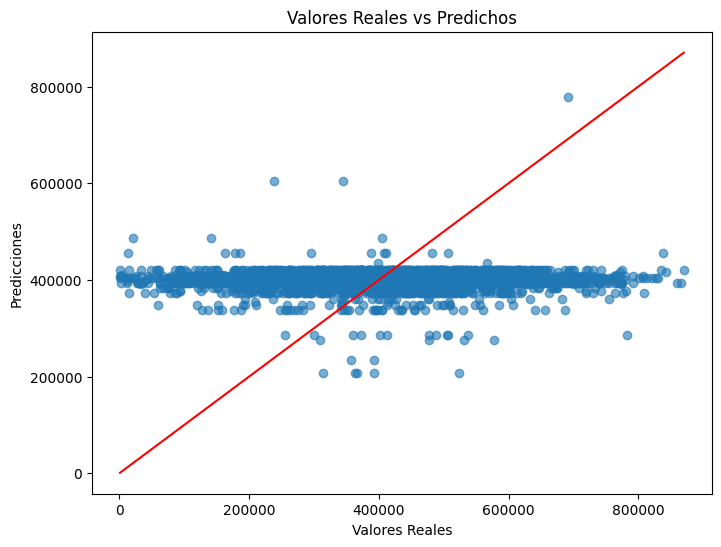

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Valores Reales vs Predichos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

**En el gráfico se observa que:**

la mayoría de las predicciones se concentran alrededor de un mismo rango,
independientemente del valor real del gasto mensual.

Esto significa que el modelo está prediciendo valores muy similares para casi todos los clientes, en lugar de adaptarse correctamente a las variaciones reales del gasto.

##Grafico de barras comparando modelo de regresion lineal y de arbol (sin hiperparametros)

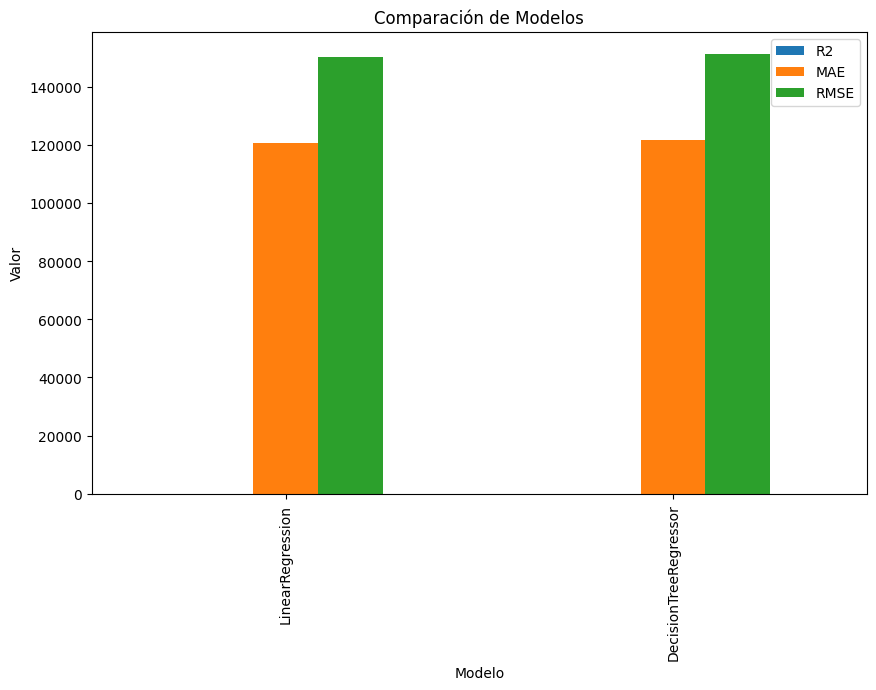

In [ ]:
metricas = pd.DataFrame({
    'Modelo': ['LinearRegression', 'DecisionTreeRegressor'],
    'R2': [r2_lr, r2_tree],
    'MAE': [mae_lr, mae_tree],
    'RMSE': [rmse_lr, rmse_tree]
})

metricas.set_index('Modelo').plot(kind='bar', figsize=(10,6))

plt.title("Comparación de Modelos")
plt.ylabel("Valor")

plt.show()

**Breve conclusion**

Los resultados obtenidos muestran que ninguno de los modelos logra explicar adecuadamente la variabilidad del gasto mensual. Sin embargo, LinearRegression presentó un desempeño ligeramente superior y una mayor interpretabilidad, lo que lo convierte en una mejor alternativa para analizar tendencias generales del comportamiento de gasto|

##Comparacion arbol de regresion con y sin hiperparametros

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['Árbol Original', 'Árbol Optimizado'],
    'MAE': [mae_tree, mae_best],
    'RMSE': [rmse_tree, rmse_best],
    'R2': [r2_tree, r2_best]
})

comparacion

,Modelo,MAE,RMSE,R2
0,Árbol Original,121574.251643,151269.820137,-0.014803
1,Árbol Optimizado,120643.441236,150413.554058,-0.003347


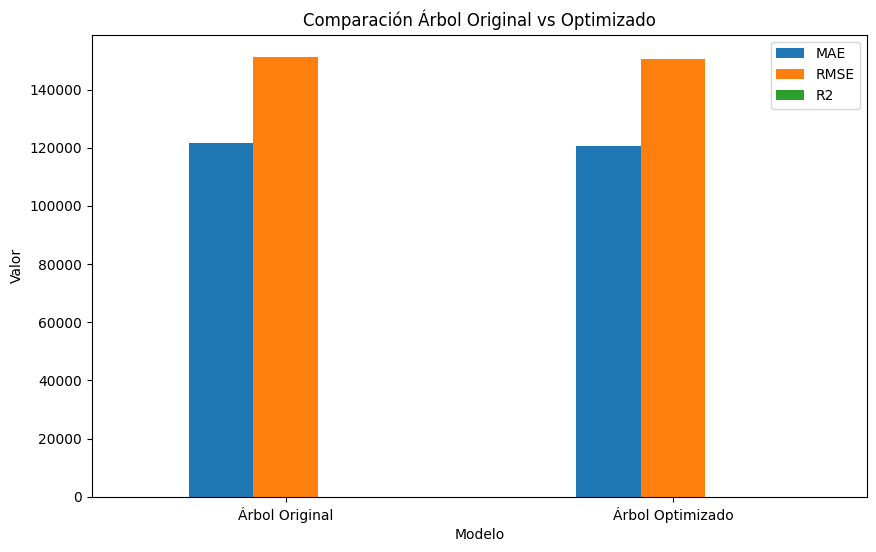

In [ ]:
comparacion.set_index('Modelo').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparación Árbol Original vs Optimizado")
plt.ylabel("Valor")
plt.xticks(rotation=0)

plt.show()